# OpenMLS Resource Metrics Analysis

Dedicated analysis for the four operation-attributed resource metrics in OpenMLS `events.csv`.

The metrics are interpreted as host-specific resource-pressure signals. Docker CPU/RAM envelopes are reproducible local proxies, not exact hardware equivalence.

In [1]:
library(dplyr)
library(tidyr)
library(purrr)
library(readr)
library(ggplot2)
library(glue)

options(repr.plot.width = 23, repr.plot.height = 16)

openmls_worker_palette <- c(
  "other workers" = "black",
  "pico-plus" = "red",
  "Raspberry Pi 5" = "#0072B2"
)

resource_metric_labels <- c(
  cpu_envelope_utilization = "CPU envelope utilization",
  cpu_throttled_time_ratio = "CPU throttled time ratio",
  ram_rss_delta_bytes = "RAM RSS delta bytes",
  ram_rss_utilization = "RAM RSS utilization"
)

resource_metrics <- names(resource_metric_labels)

classify_openmls_workers <- function(df) {
  if (!"client_id" %in% names(df)) df$client_id <- NA_character_
  if (!"worker_id" %in% names(df)) df$worker_id <- NA_character_
  if (!"device_kind" %in% names(df)) df$device_kind <- NA_character_
  if (!"resource_profile" %in% names(df)) df$resource_profile <- NA_character_
  if (!"resource_limit_cpus" %in% names(df)) df$resource_limit_cpus <- NA_real_
  if (!"resource_limit_memory" %in% names(df)) df$resource_limit_memory <- NA_character_

  df |>
    mutate(
      n_members = member_count,
      resource_profile_chr = as.character(resource_profile),
      resource_limit_memory_chr = as.character(resource_limit_memory),
      worker_group = case_when(
        !is.na(device_kind) & device_kind == "raspberry_pi_5" ~ "Raspberry Pi 5",
        !is.na(client_id) & grepl("^raspi5-", as.character(client_id)) ~ "Raspberry Pi 5",
        !is.na(worker_id) & grepl("^raspi5-", as.character(worker_id)) ~ "Raspberry Pi 5",
        !is.na(device_kind) & device_kind == "luckfox_pico_plus" ~ "pico-plus",
        !is.na(client_id) & grepl("^pico-plus-", as.character(client_id)) ~ "pico-plus",
        !is.na(worker_id) & grepl("^pico-plus-", as.character(worker_id)) ~ "pico-plus",
        TRUE ~ "other workers"
      ),
      worker_group = factor(worker_group, levels = names(openmls_worker_palette)),
      resource_envelope = case_when(
        !is.na(resource_profile_chr) & resource_profile_chr != "" ~ resource_profile_chr,
        !is.na(resource_limit_cpus) | (!is.na(resource_limit_memory_chr) & resource_limit_memory_chr != "") ~ paste0(
          "cpus=", if_else(is.na(resource_limit_cpus), "", as.character(resource_limit_cpus)),
          ", memory=", if_else(is.na(resource_limit_memory_chr), "", resource_limit_memory_chr)
        ),
        TRUE ~ "unconstrained / external"
      )
    )
}

read_openmls_resource_events <- function() {
  files <- unique(c(
    Sys.glob("OpenMLS_containerized/benchmark_output/*/events.csv"),
    Sys.glob("OpenMLS_containerized/OpenMLS_containerized/benchmark_output/*/events.csv")
  ))
  if (length(files) == 0) stop("No OpenMLS events.csv files found")

  map_dfr(files, function(path) {
    read_csv(path, show_col_types = FALSE) |>
      mutate(
        source_path = path,
        run_id_from_path = basename(dirname(path))
      )
  }) |>
    classify_openmls_workers()
}

omls_resource <- read_openmls_resource_events()

present_resource_metrics <- intersect(resource_metrics, names(omls_resource))
missing_resource_metrics <- setdiff(resource_metrics, present_resource_metrics)

if (length(missing_resource_metrics) > 0) {
  message("Missing resource metric columns: ", paste(missing_resource_metrics, collapse = ", "))
}

if (length(present_resource_metrics) == 0) {
  stop("No resource metric columns found. Re-run OpenMLS with the refactored profiler first.")
}

omls_resource_long <- omls_resource |>
  pivot_longer(
    all_of(present_resource_metrics),
    names_to = "metric",
    values_to = "value"
  ) |>
  mutate(
    metric_label = unname(resource_metric_labels[metric]),
    metric_label = if_else(is.na(metric_label), metric, metric_label),
    metric_label = factor(metric_label, levels = unname(resource_metric_labels[present_resource_metrics]))
  )

cat("OpenMLS event rows:", nrow(omls_resource), "\n")
cat("OpenMLS runs:", length(unique(omls_resource$run_id_from_path)), "\n")
cat("Resource metrics:", paste(present_resource_metrics, collapse = ", "), "\n")



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




OpenMLS event rows: 98744 
OpenMLS runs: 17 
Resource metrics: cpu_envelope_utilization, cpu_throttled_time_ratio, ram_rss_delta_bytes, ram_rss_utilization 


## Missingness And Run Coverage

This confirms which runs contain the new metric columns and how much data is available per operation.

In [2]:
run_coverage <- omls_resource_long |>
  group_by(run_id_from_path, resource_envelope, metric_label) |>
  summarise(
    rows = n(),
    non_missing = sum(!is.na(value)),
    missing = sum(is.na(value)),
    pct_missing = 100 * missing / rows,
    .groups = "drop"
  ) |>
  arrange(run_id_from_path, metric_label)

print(run_coverage, n = Inf)

operation_coverage <- omls_resource_long |>
  group_by(op, metric_label) |>
  summarise(
    rows = n(),
    non_missing = sum(!is.na(value)),
    missing = sum(is.na(value)),
    pct_missing = 100 * missing / rows,
    .groups = "drop"
  ) |>
  arrange(op, metric_label)

print(operation_coverage, n = Inf)


# A tibble: 68 × 7
   run_id_from_path     resource_envelope metric_label  rows non_missing missing
   <chr>                <chr>             <fct>        <int>       <int>   <int>
 1 codex-openmls-l1d-5… unconstrained / … CPU envelop…   497         497       0
 2 codex-openmls-l1d-5… unconstrained / … CPU throttl…   497         497       0
 3 codex-openmls-l1d-5… unconstrained / … RAM RSS del…   497         497       0
 4 codex-openmls-l1d-5… unconstrained / … RAM RSS uti…   497         497       0
 5 openmls_run_10_2026… unconstrained / … CPU envelop…  6353        6353       0
 6 openmls_run_10_2026… unconstrained / … CPU throttl…  6353        6353       0
 7 openmls_run_10_2026… unconstrained / … RAM RSS del…  6353        6353       0
 8 openmls_run_10_2026… unconstrained / … RAM RSS uti…  6353        6353       0
 9 openmls_run_11_2026… unconstrained / … CPU envelop…  6619        6619       0
10 openmls_run_11_2026… unconstrained / … CPU throttl…  6619        6619       0
11 openml

## Operation Summary

Median, IQR, p95, and maximum per OpenMLS operation and metric. This is the compact table to use when identifying hard-hitting operations.

In [3]:
openmls_resource_operation_summary <- omls_resource_long |>
  filter(!is.na(value)) |>
  group_by(op, metric_label) |>
  summarise(
    rows = n(),
    median = median(value, na.rm = TRUE),
    q25 = quantile(value, 0.25, na.rm = TRUE),
    q75 = quantile(value, 0.75, na.rm = TRUE),
    iqr = IQR(value, na.rm = TRUE),
    p95 = quantile(value, 0.95, na.rm = TRUE),
    max = max(value, na.rm = TRUE),
    .groups = "drop"
  ) |>
  arrange(op, metric_label)

print(openmls_resource_operation_summary, n = Inf)


# A tibble: 52 × 9
   op         metric_label  rows  median     q25     q75     iqr     p95     max
   <chr>      <fct>        <int>   <dbl>   <dbl>   <dbl>   <dbl>   <dbl>   <dbl>
 1 applicati… CPU envelop… 15797 1.12e+0 1.11e+0 1.15e+0 3.67e-2 1.20e+0 1.48e+0
 2 applicati… CPU throttl… 15797 0       0       0       0       0       0      
 3 applicati… RAM RSS del… 15797 8.19e+3 0       1.64e+4 1.64e+4 2.87e+4 5.73e+4
 4 applicati… RAM RSS uti… 15797 4.39e-4 3.95e-4 4.75e-4 8.02e-5 5.49e-4 6.20e-4
 5 applicati… CPU envelop… 15797 1.59e+0 1.55e+0 1.61e+0 6.36e-2 1.66e+0 2.80e+0
 6 applicati… CPU throttl… 15797 0       0       0       0       0       0      
 7 applicati… RAM RSS del… 15797 0       0       0       0       0       4.10e+3
 8 applicati… RAM RSS uti… 15797 4.39e-4 3.95e-4 4.75e-4 8.02e-5 5.49e-4 6.20e-4
 9 applicati… CPU envelop… 15124 1.38e+0 1.33e+0 1.43e+0 9.26e-2 1.55e+0 3.50e+0
10 applicati… CPU throttl… 15124 0       0       0       0       0       0      
11 applic

## Operation Summary By Worker Group

Same metrics, split into containerized workers and configured external devices.

In [4]:
openmls_resource_worker_summary <- omls_resource_long |>
  filter(!is.na(value)) |>
  group_by(worker_group, resource_envelope, op, metric_label) |>
  summarise(
    rows = n(),
    median = median(value, na.rm = TRUE),
    q25 = quantile(value, 0.25, na.rm = TRUE),
    q75 = quantile(value, 0.75, na.rm = TRUE),
    p95 = quantile(value, 0.95, na.rm = TRUE),
    max = max(value, na.rm = TRUE),
    .groups = "drop"
  ) |>
  arrange(op, metric_label, worker_group, resource_envelope)

print(openmls_resource_worker_summary, n = 200)


# A tibble: 52 × 10
   worker_group  resource_envelope      op    metric_label  rows  median     q25
   <fct>         <chr>                  <chr> <fct>        <int>   <dbl>   <dbl>
 1 other workers unconstrained / exter… appl… CPU envelop… 15797 1.12e+0 1.11e+0
 2 other workers unconstrained / exter… appl… CPU throttl… 15797 0       0      
 3 other workers unconstrained / exter… appl… RAM RSS del… 15797 8.19e+3 0      
 4 other workers unconstrained / exter… appl… RAM RSS uti… 15797 4.39e-4 3.95e-4
 5 other workers unconstrained / exter… appl… CPU envelop… 15797 1.59e+0 1.55e+0
 6 other workers unconstrained / exter… appl… CPU throttl… 15797 0       0      
 7 other workers unconstrained / exter… appl… RAM RSS del… 15797 0       0      
 8 other workers unconstrained / exter… appl… RAM RSS uti… 15797 4.39e-4 3.95e-4
 9 other workers unconstrained / exter… appl… CPU envelop… 15124 1.38e+0 1.33e+0
10 other workers unconstrained / exter… appl… CPU throttl… 15124 0       0      
11 other

## Per-Operation Plots

Each plot corresponds to one OpenMLS operation. The four resource metrics are faceted inside the operation, matching the operation-first style of `statistics_analysis.ipynb`.

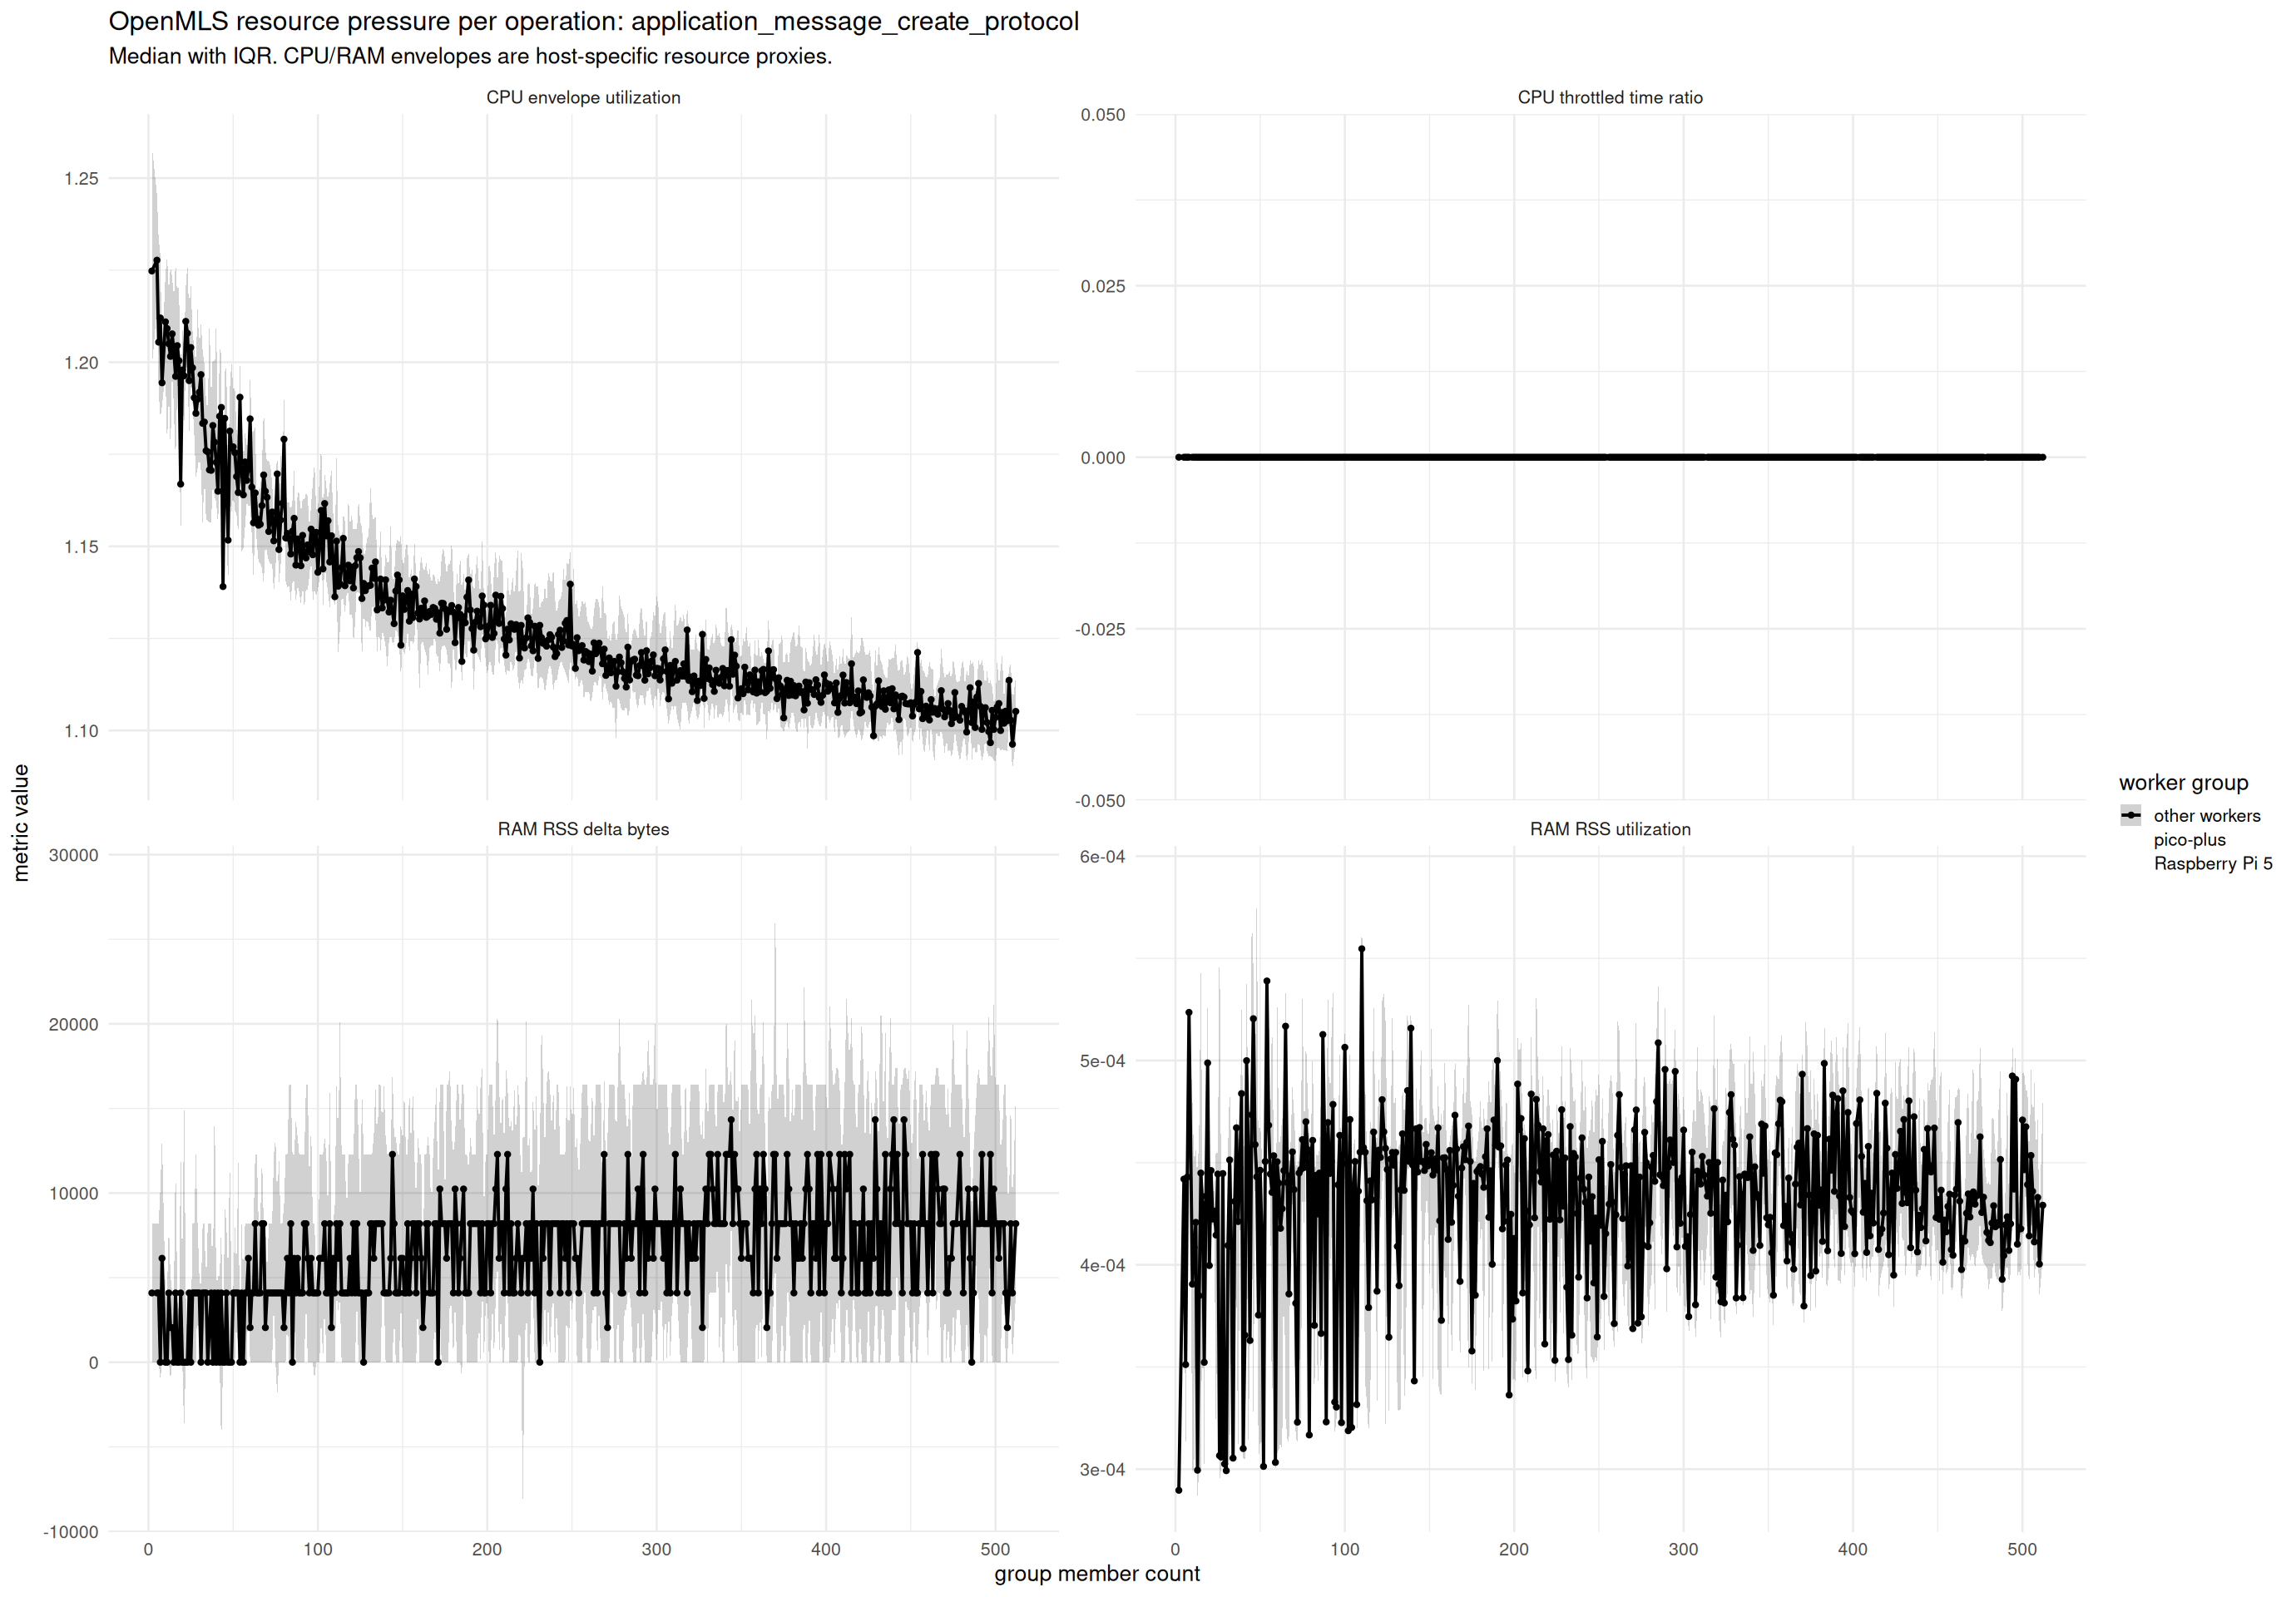

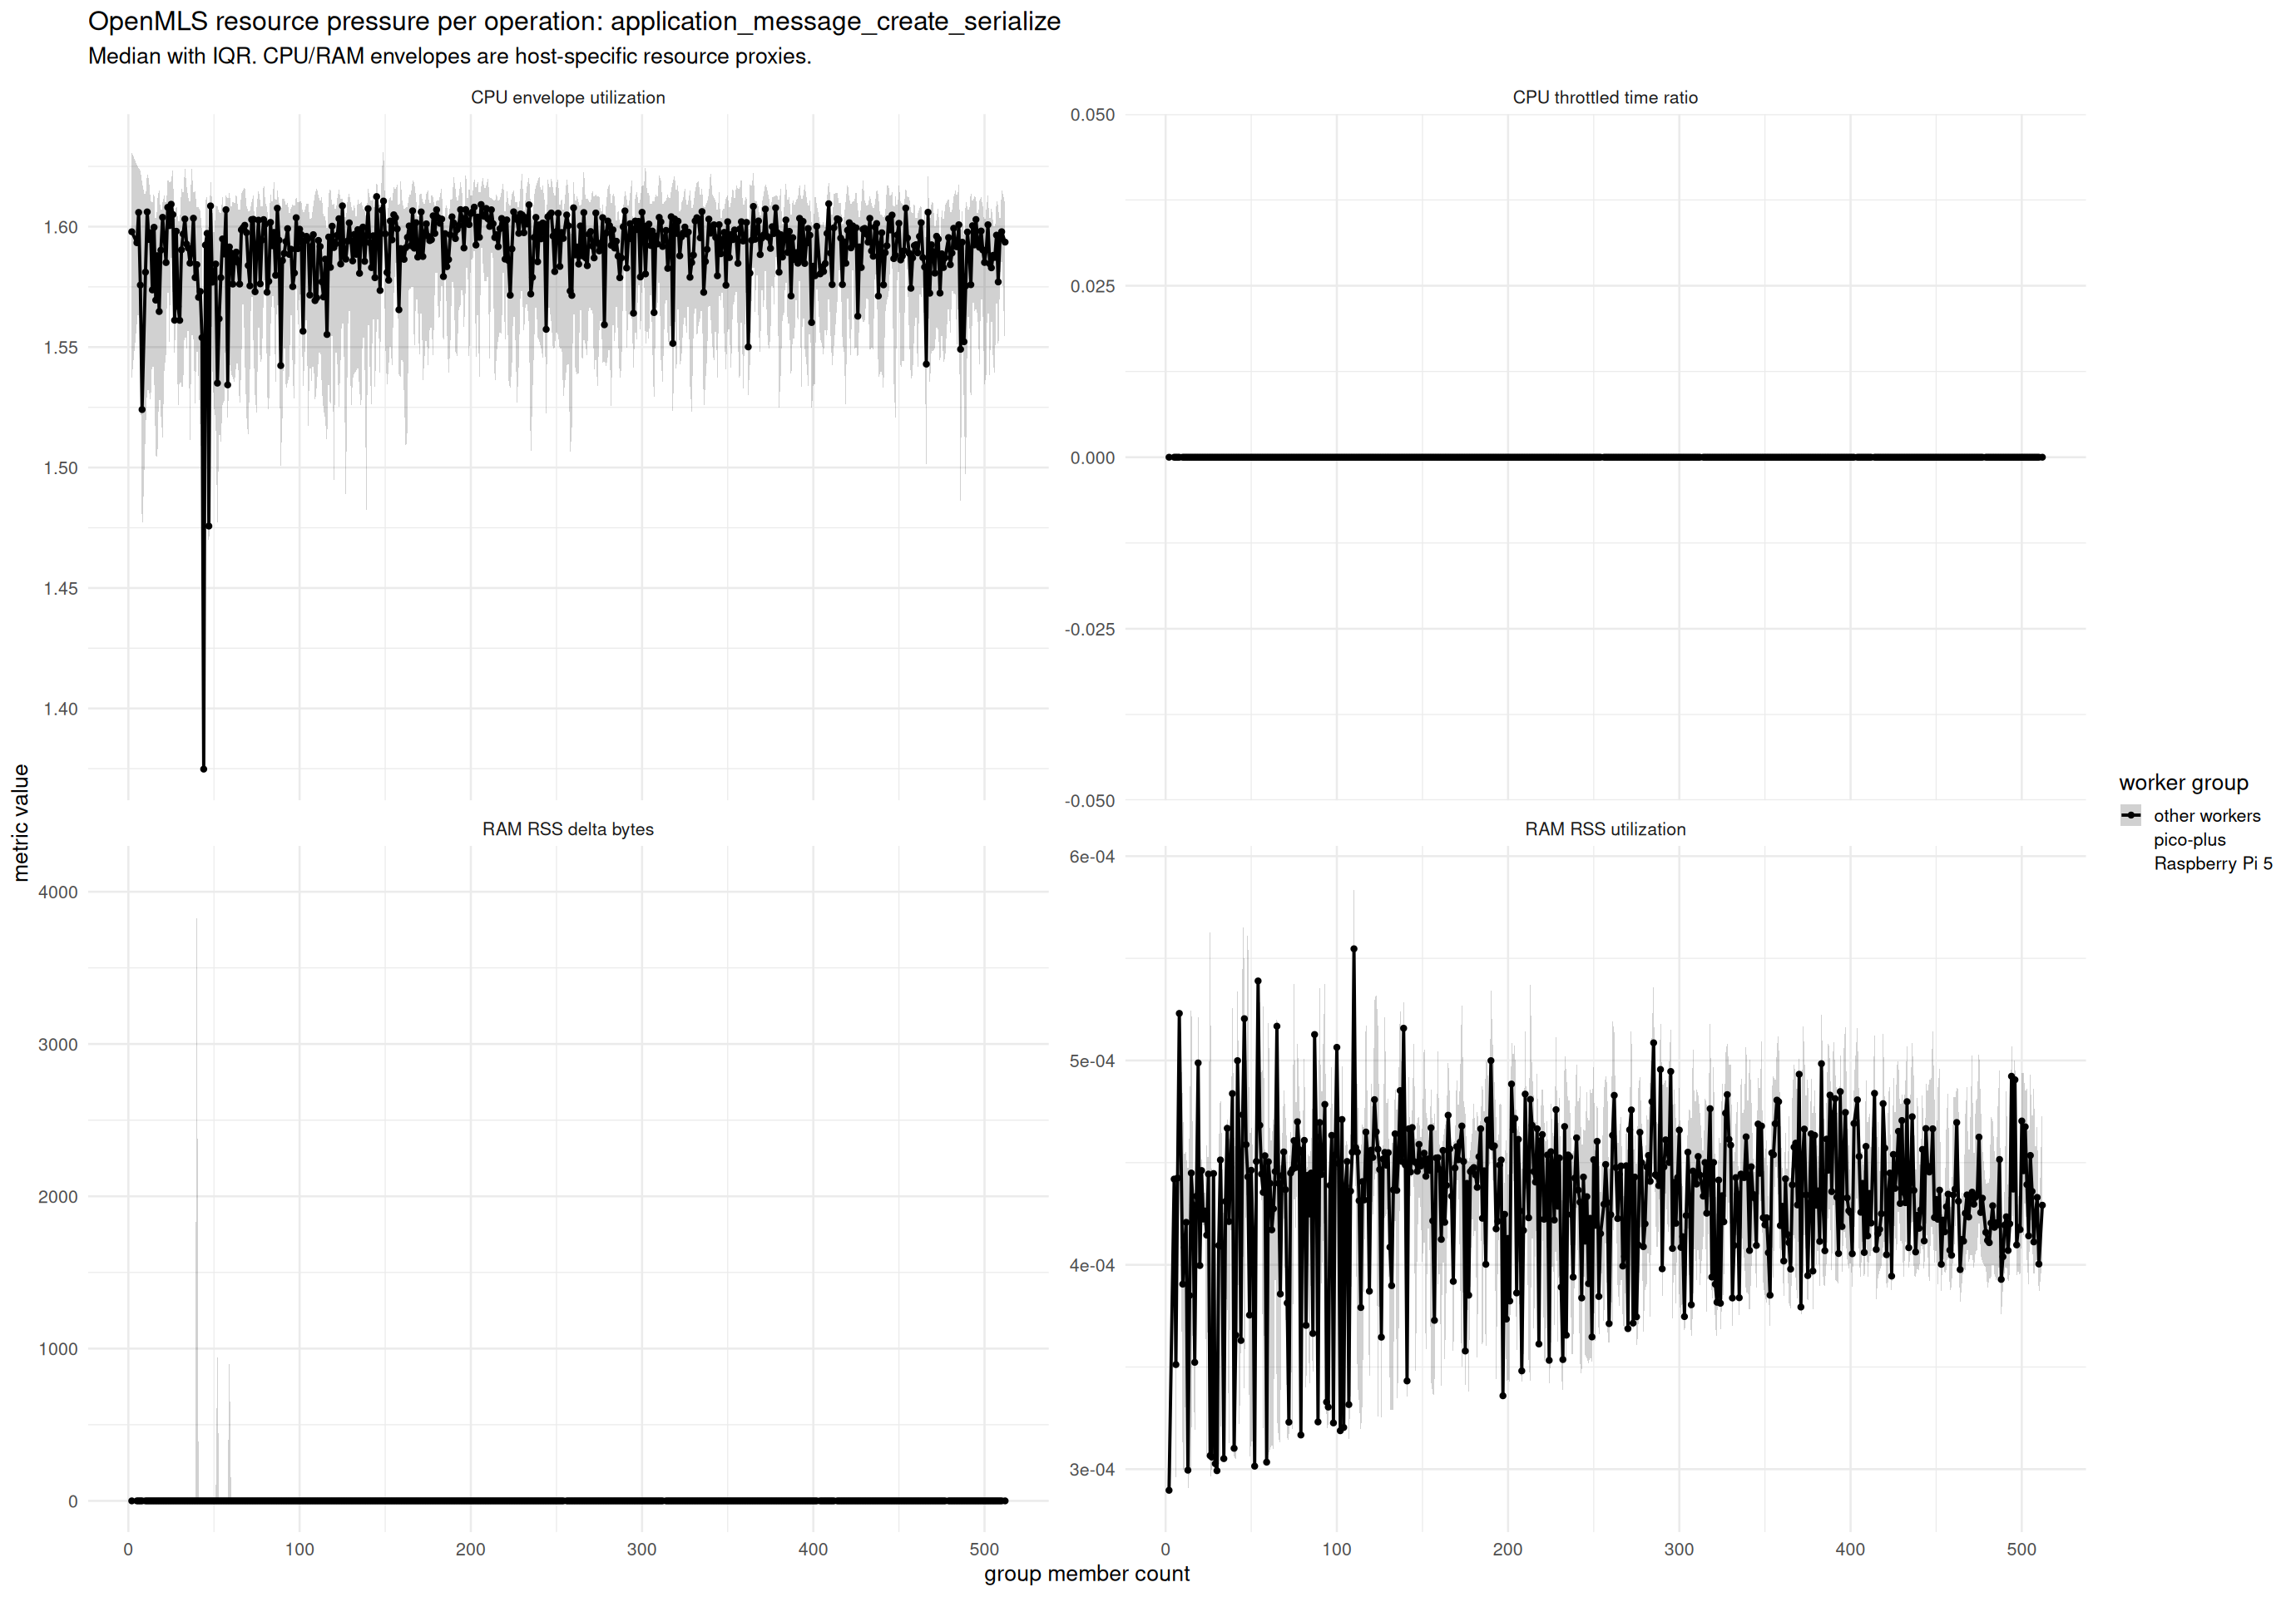

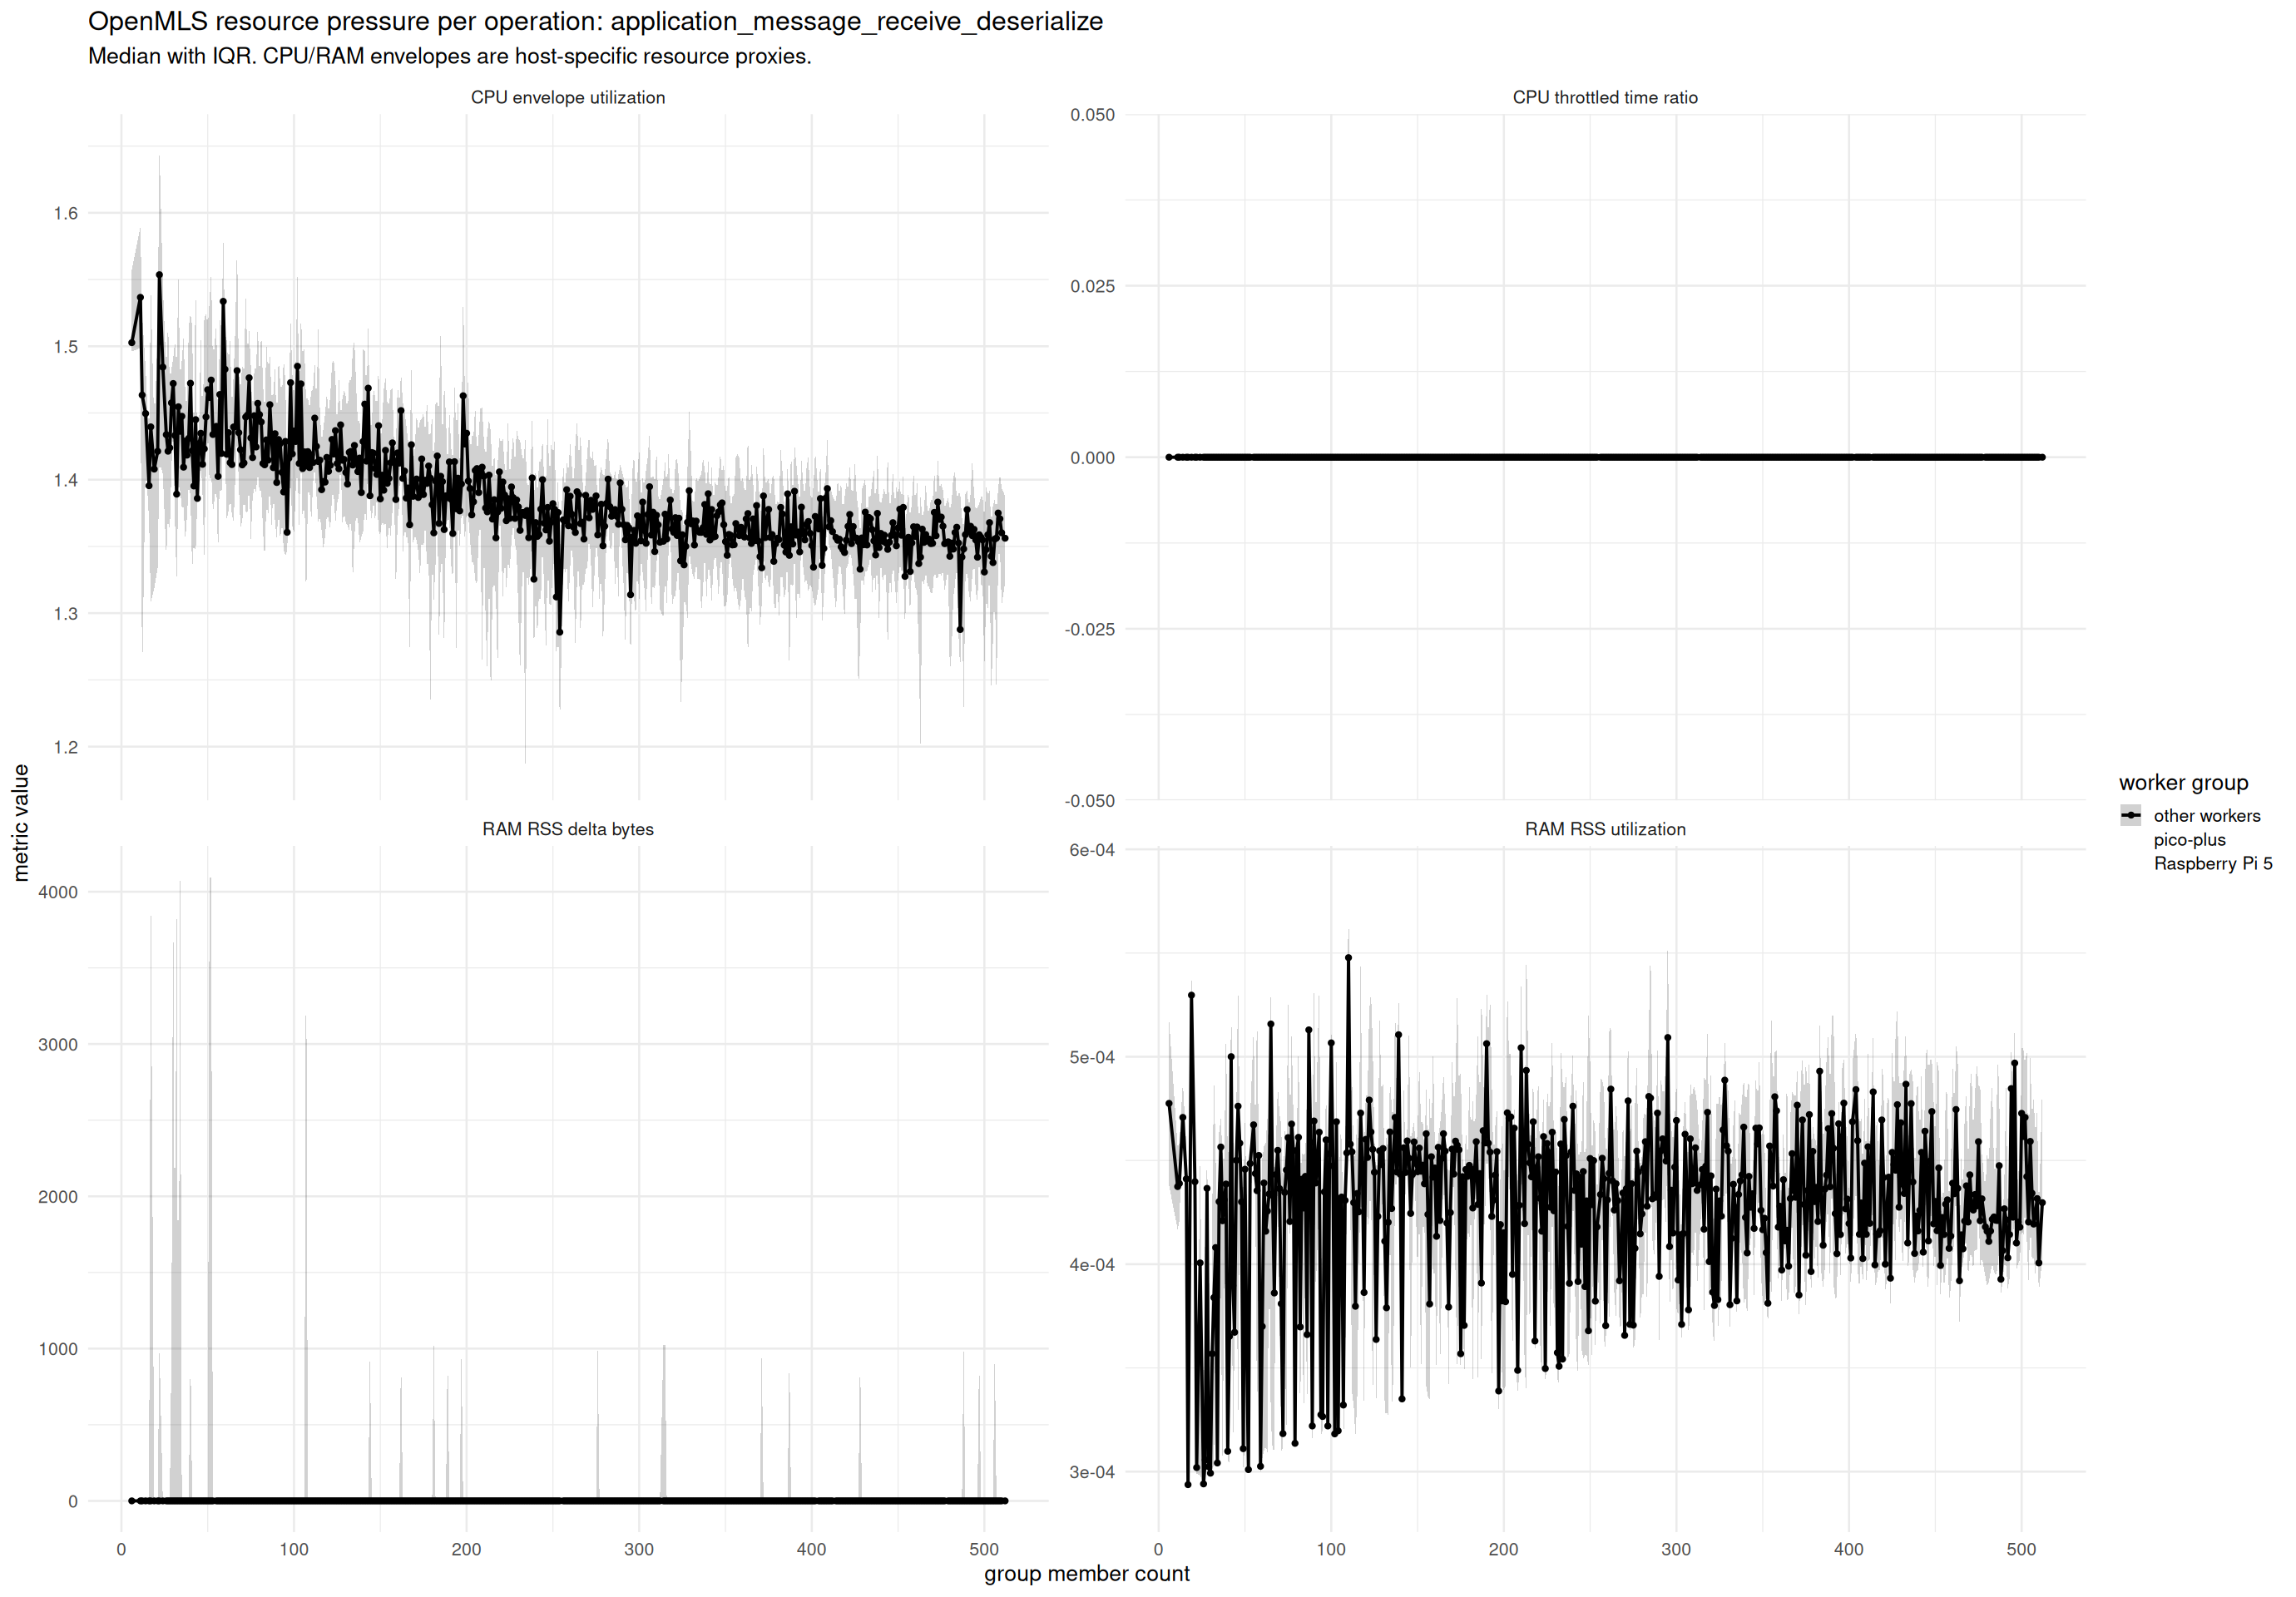

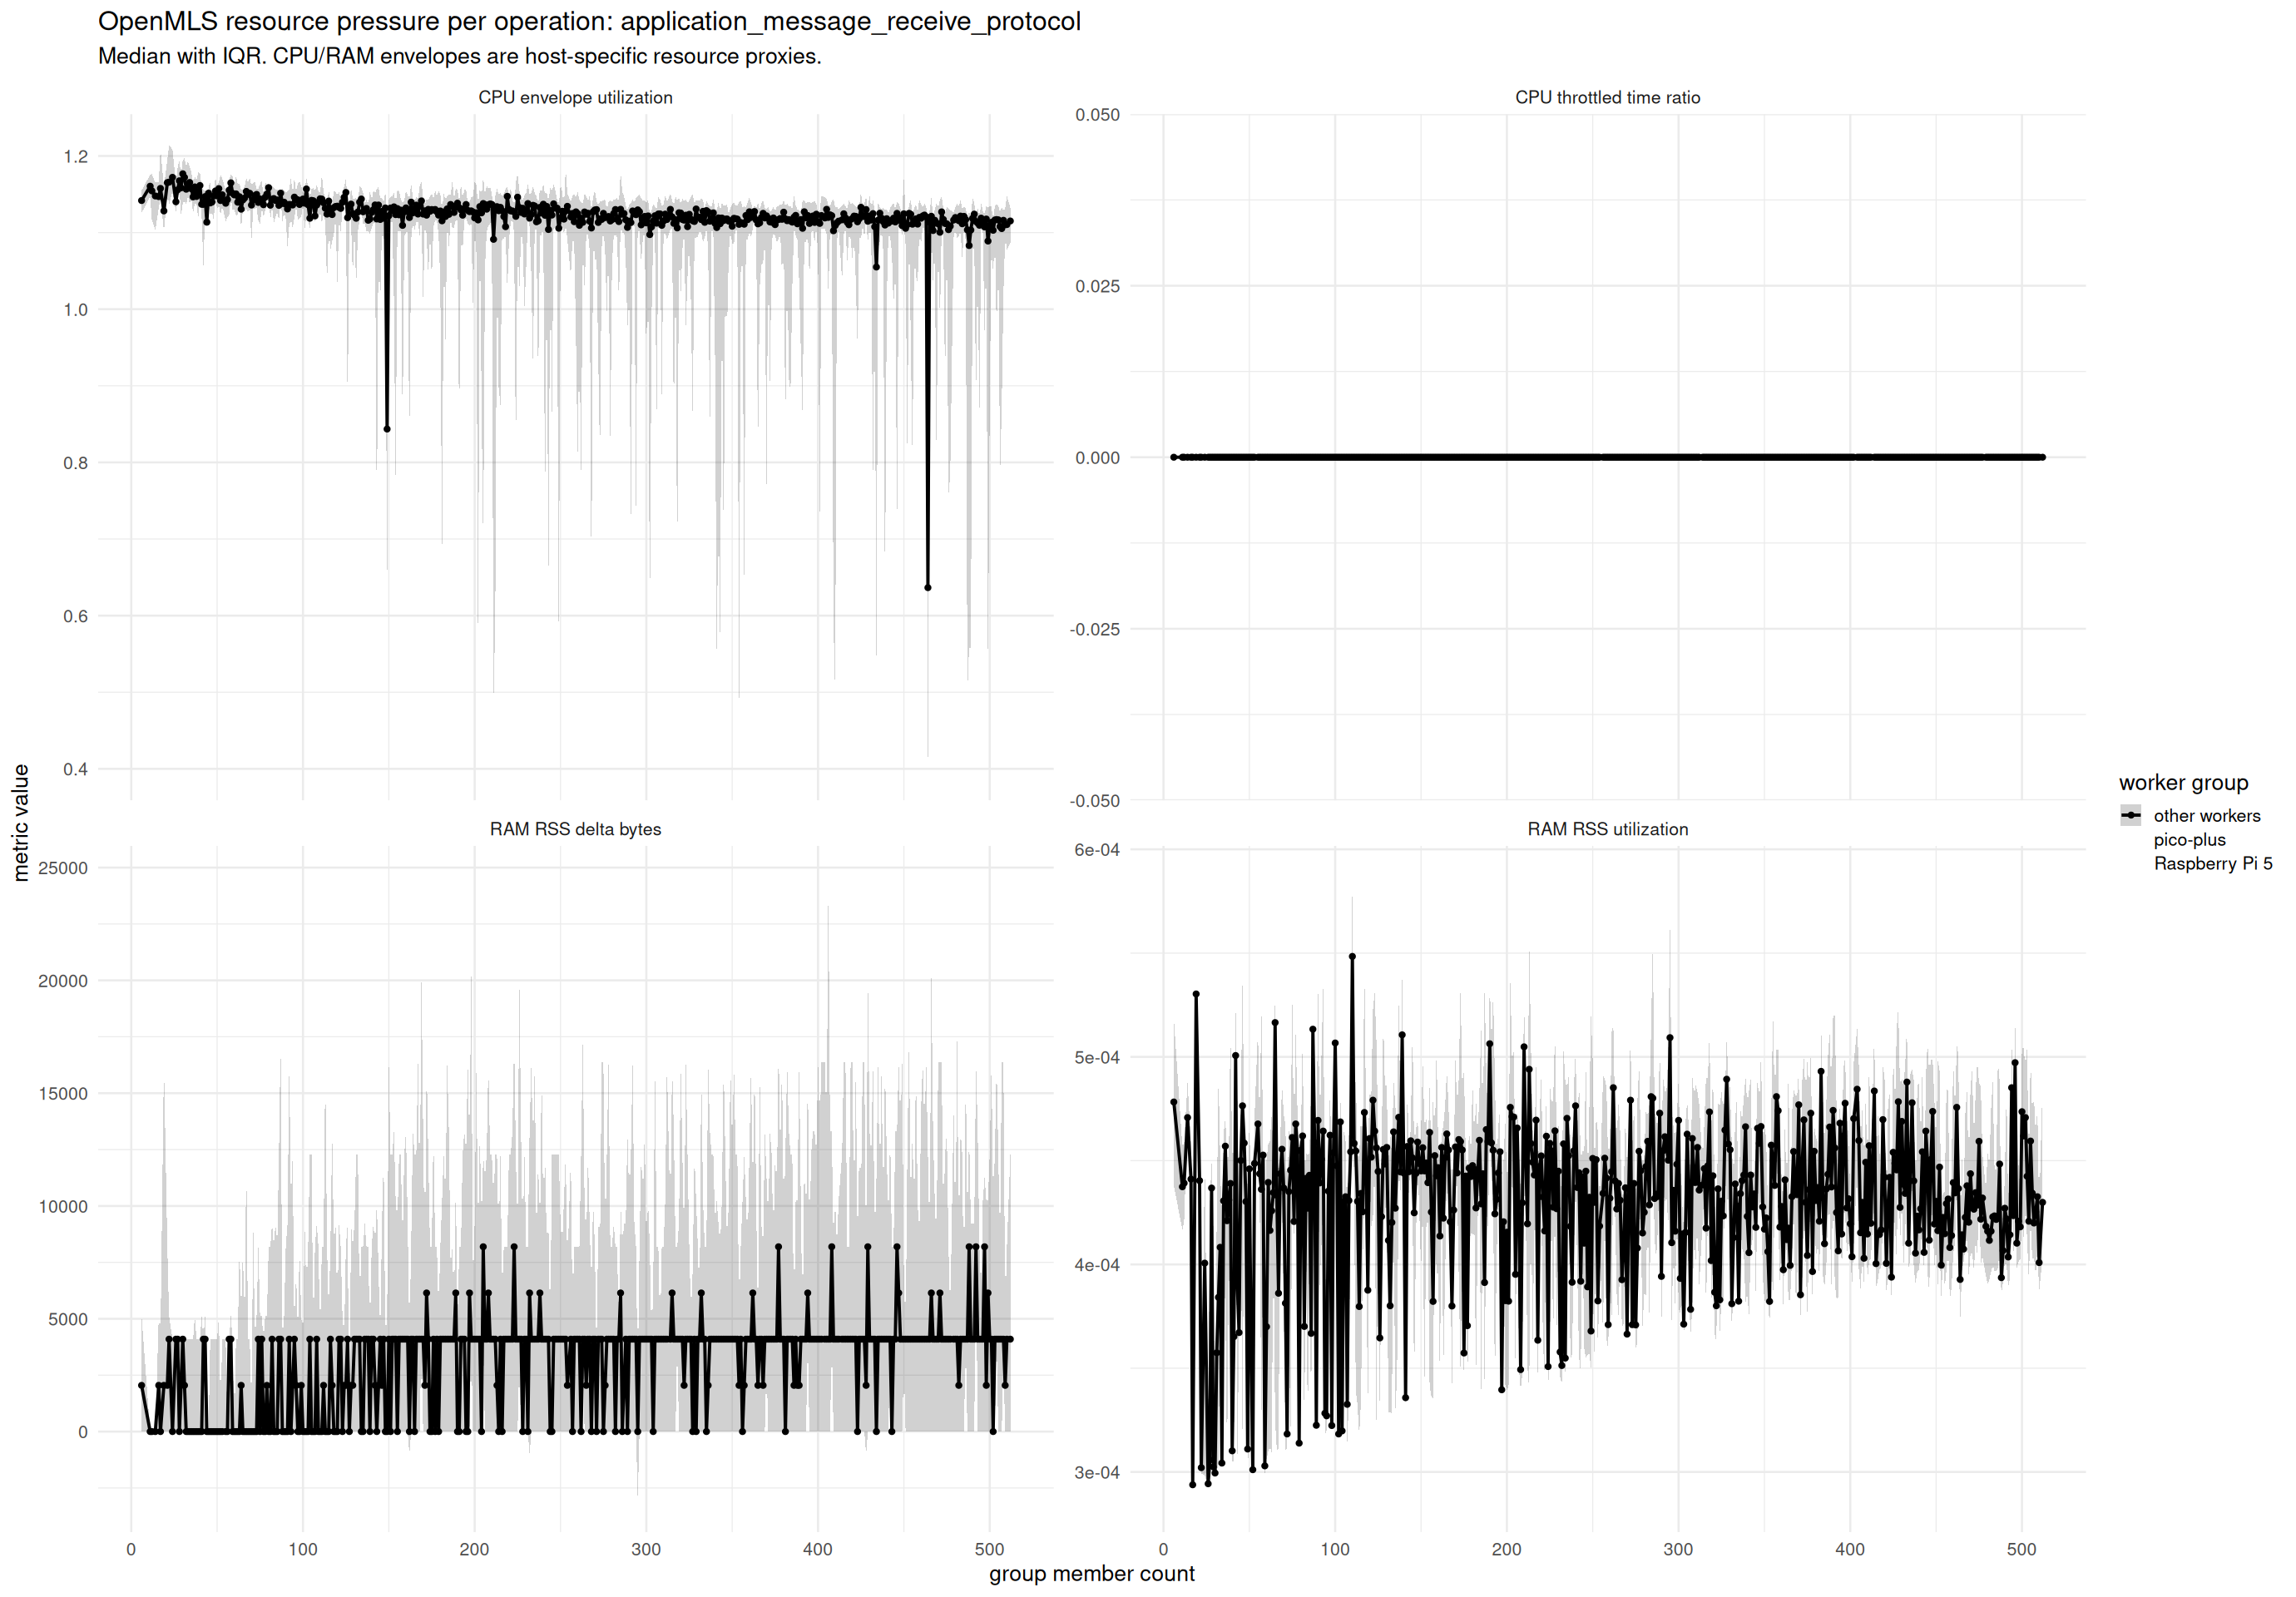

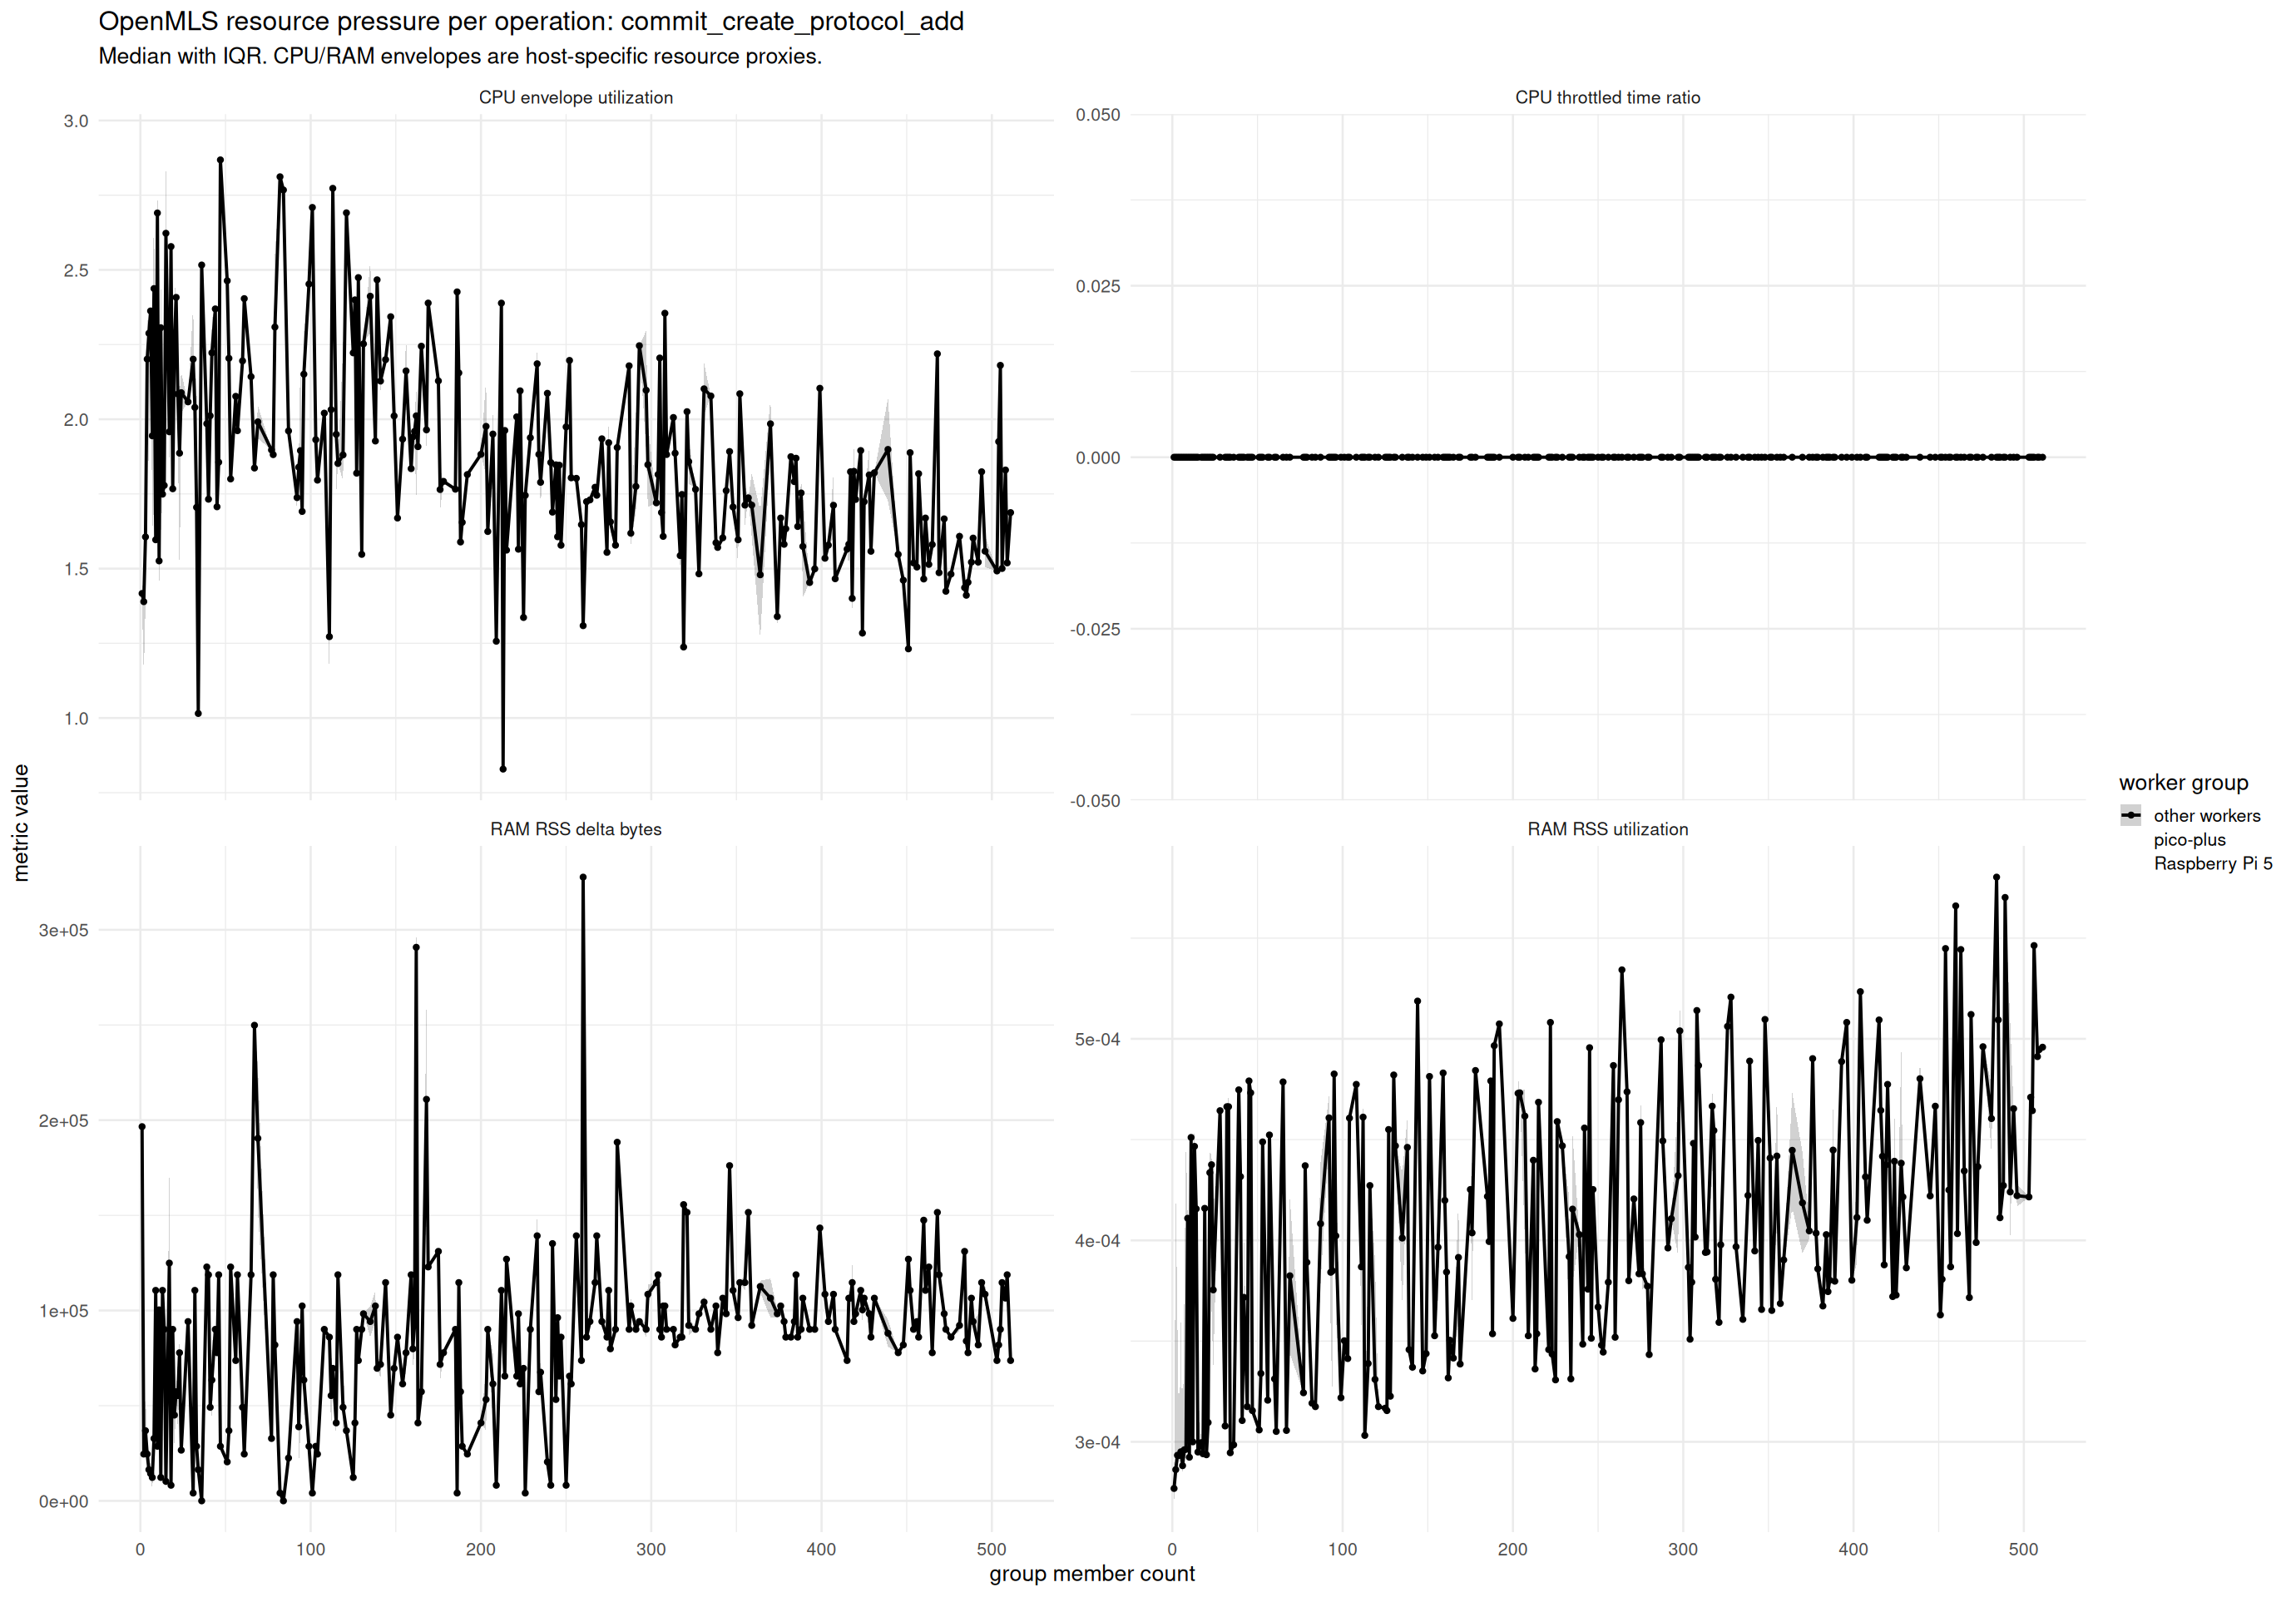

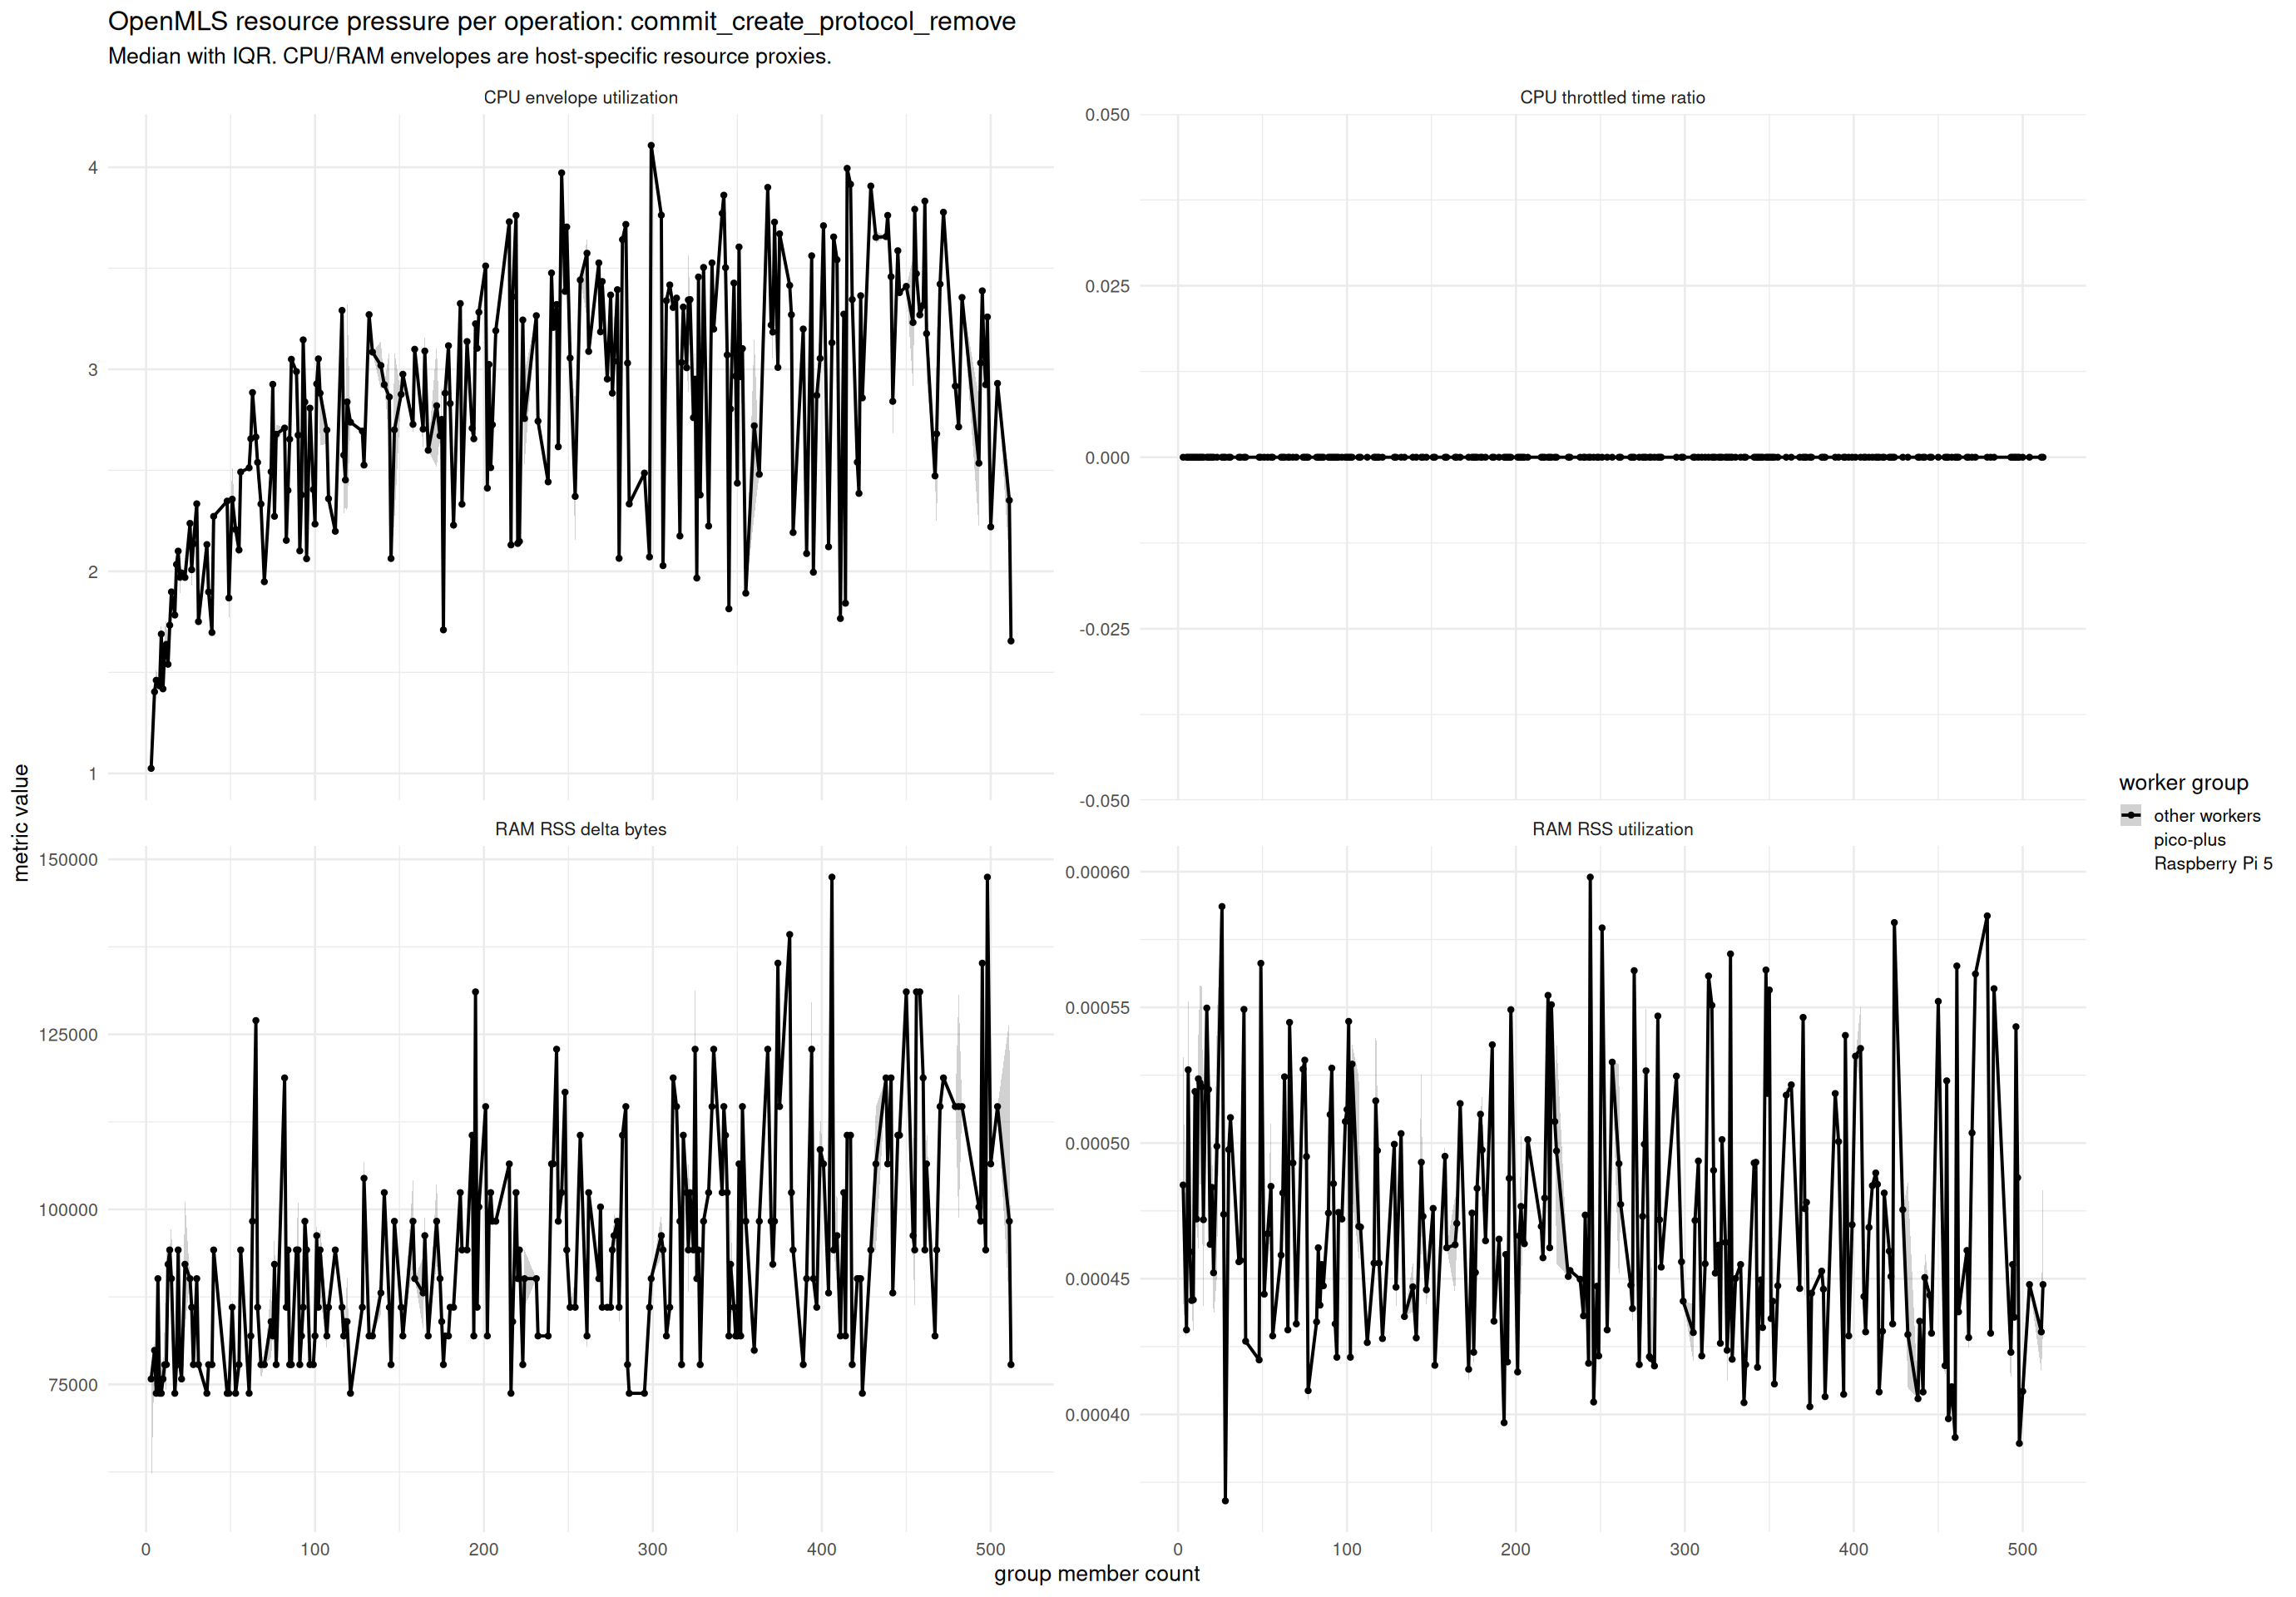

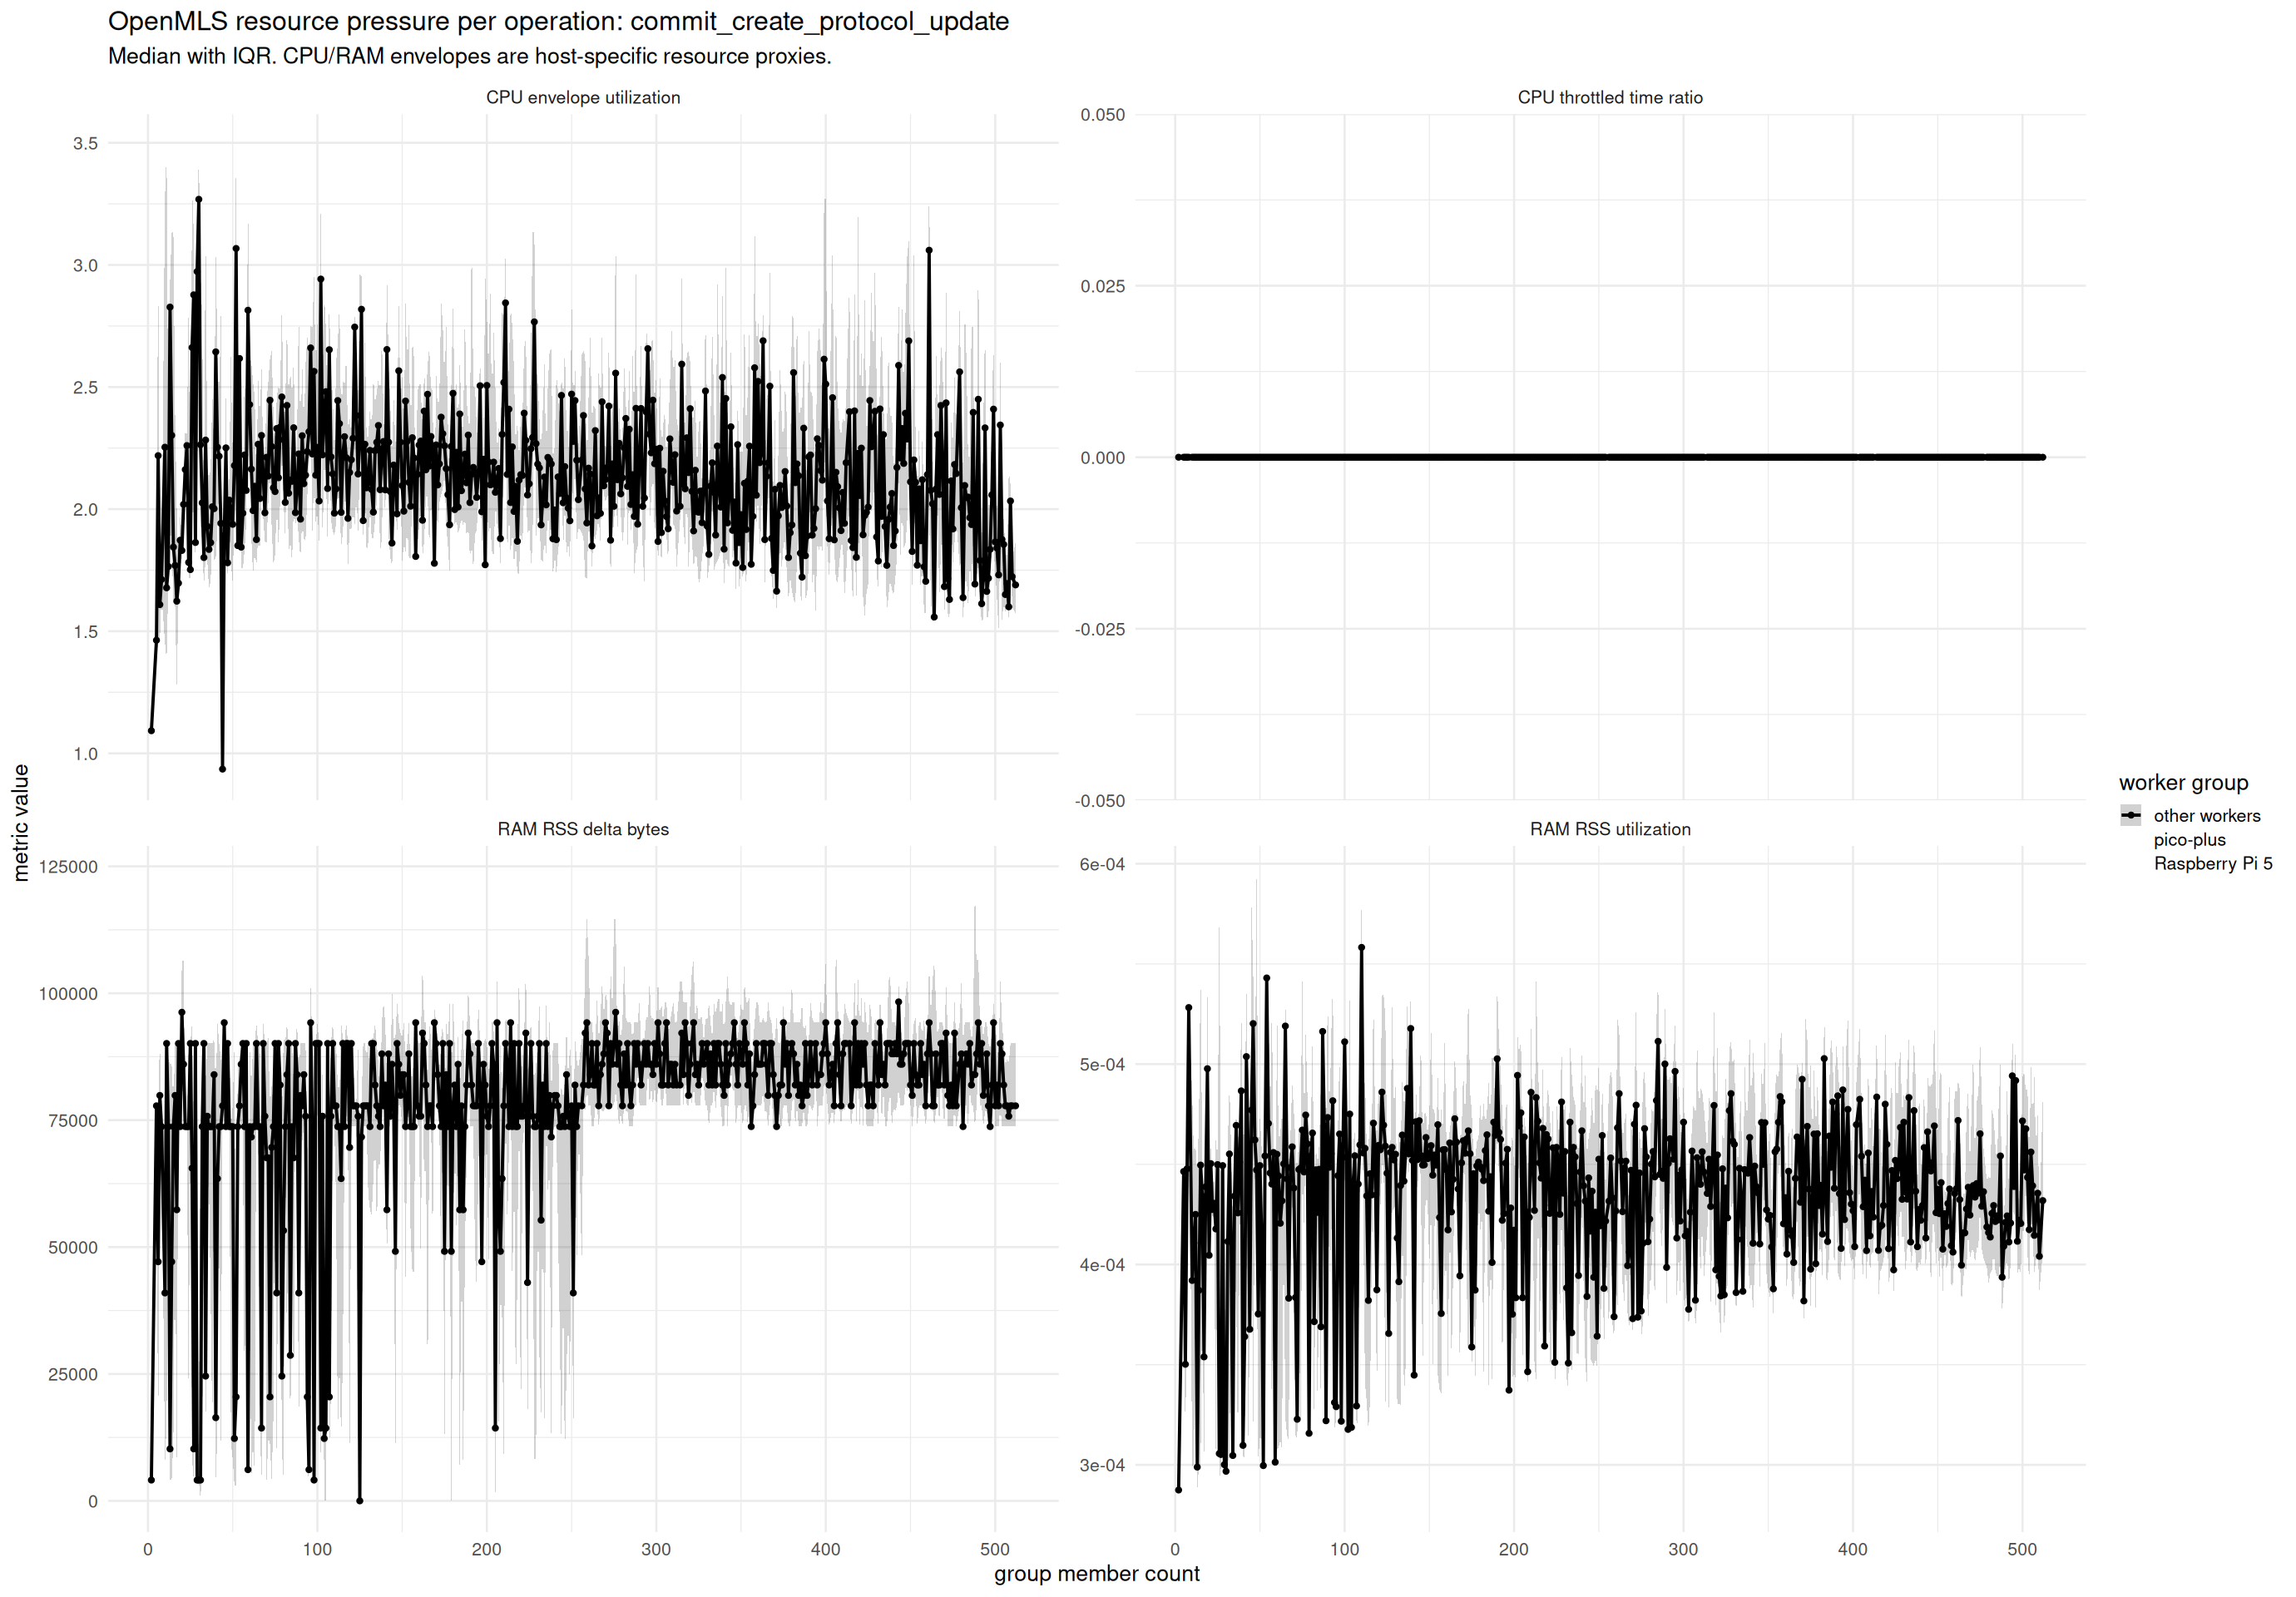

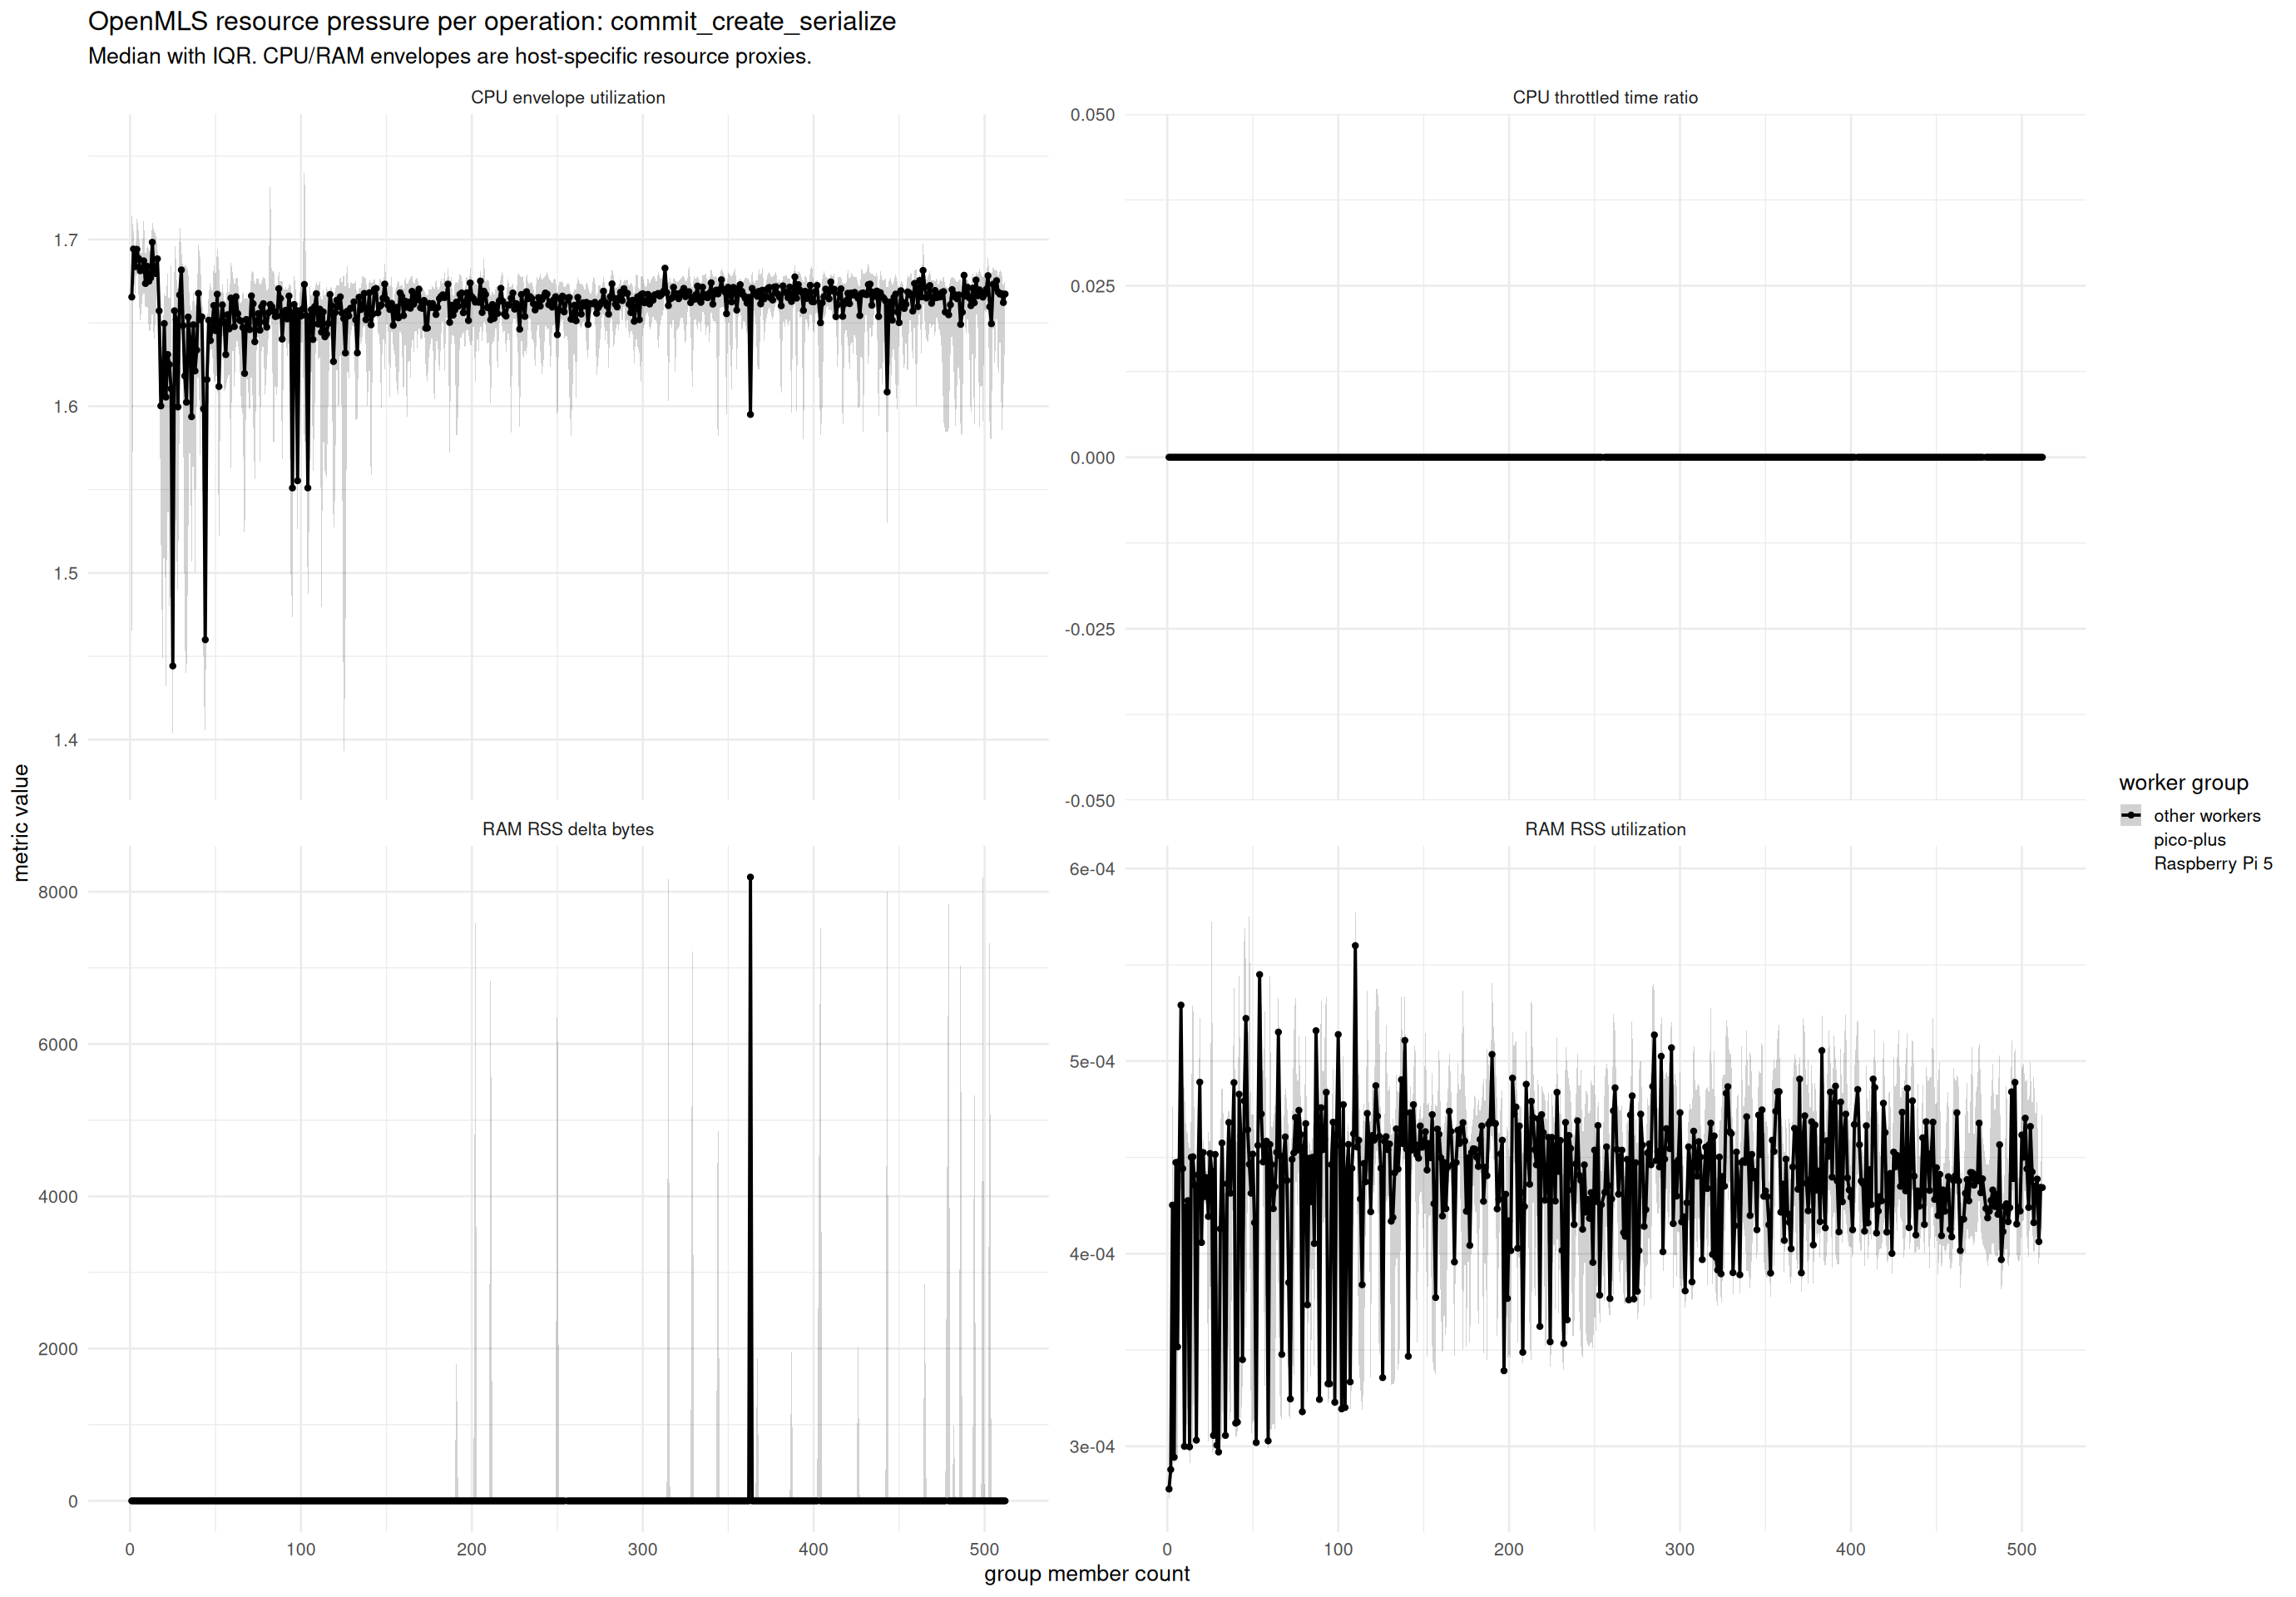

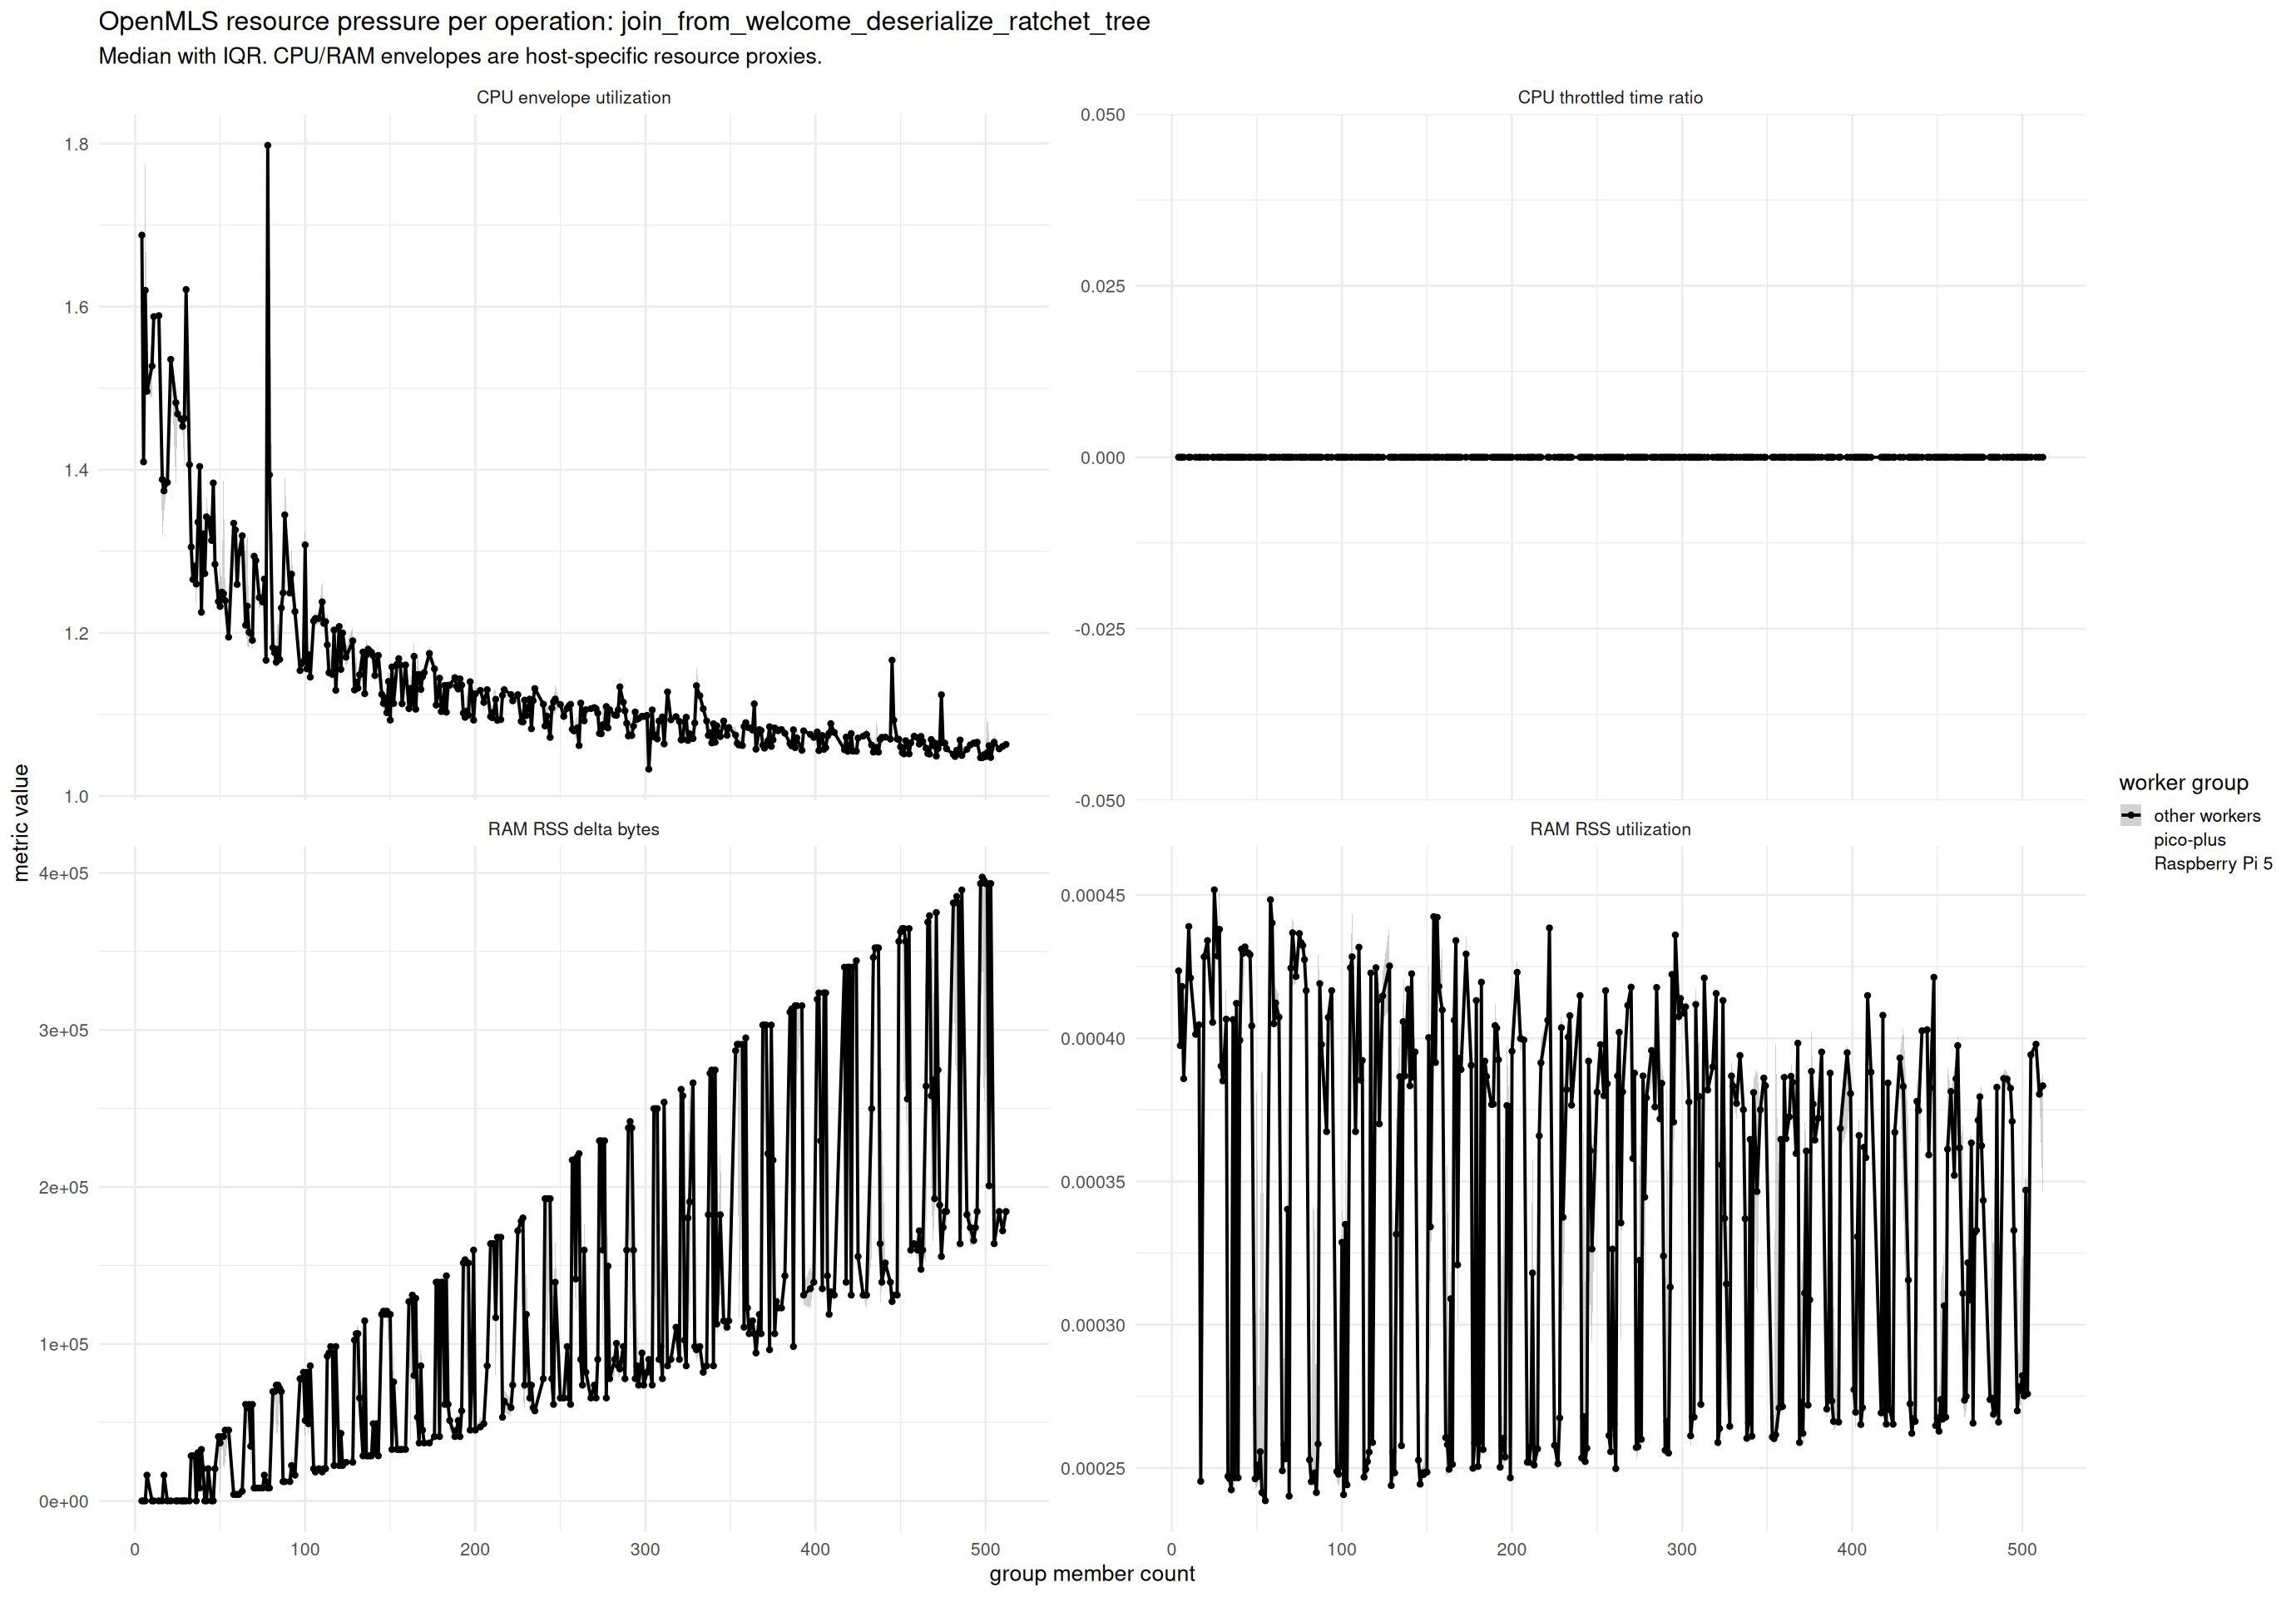

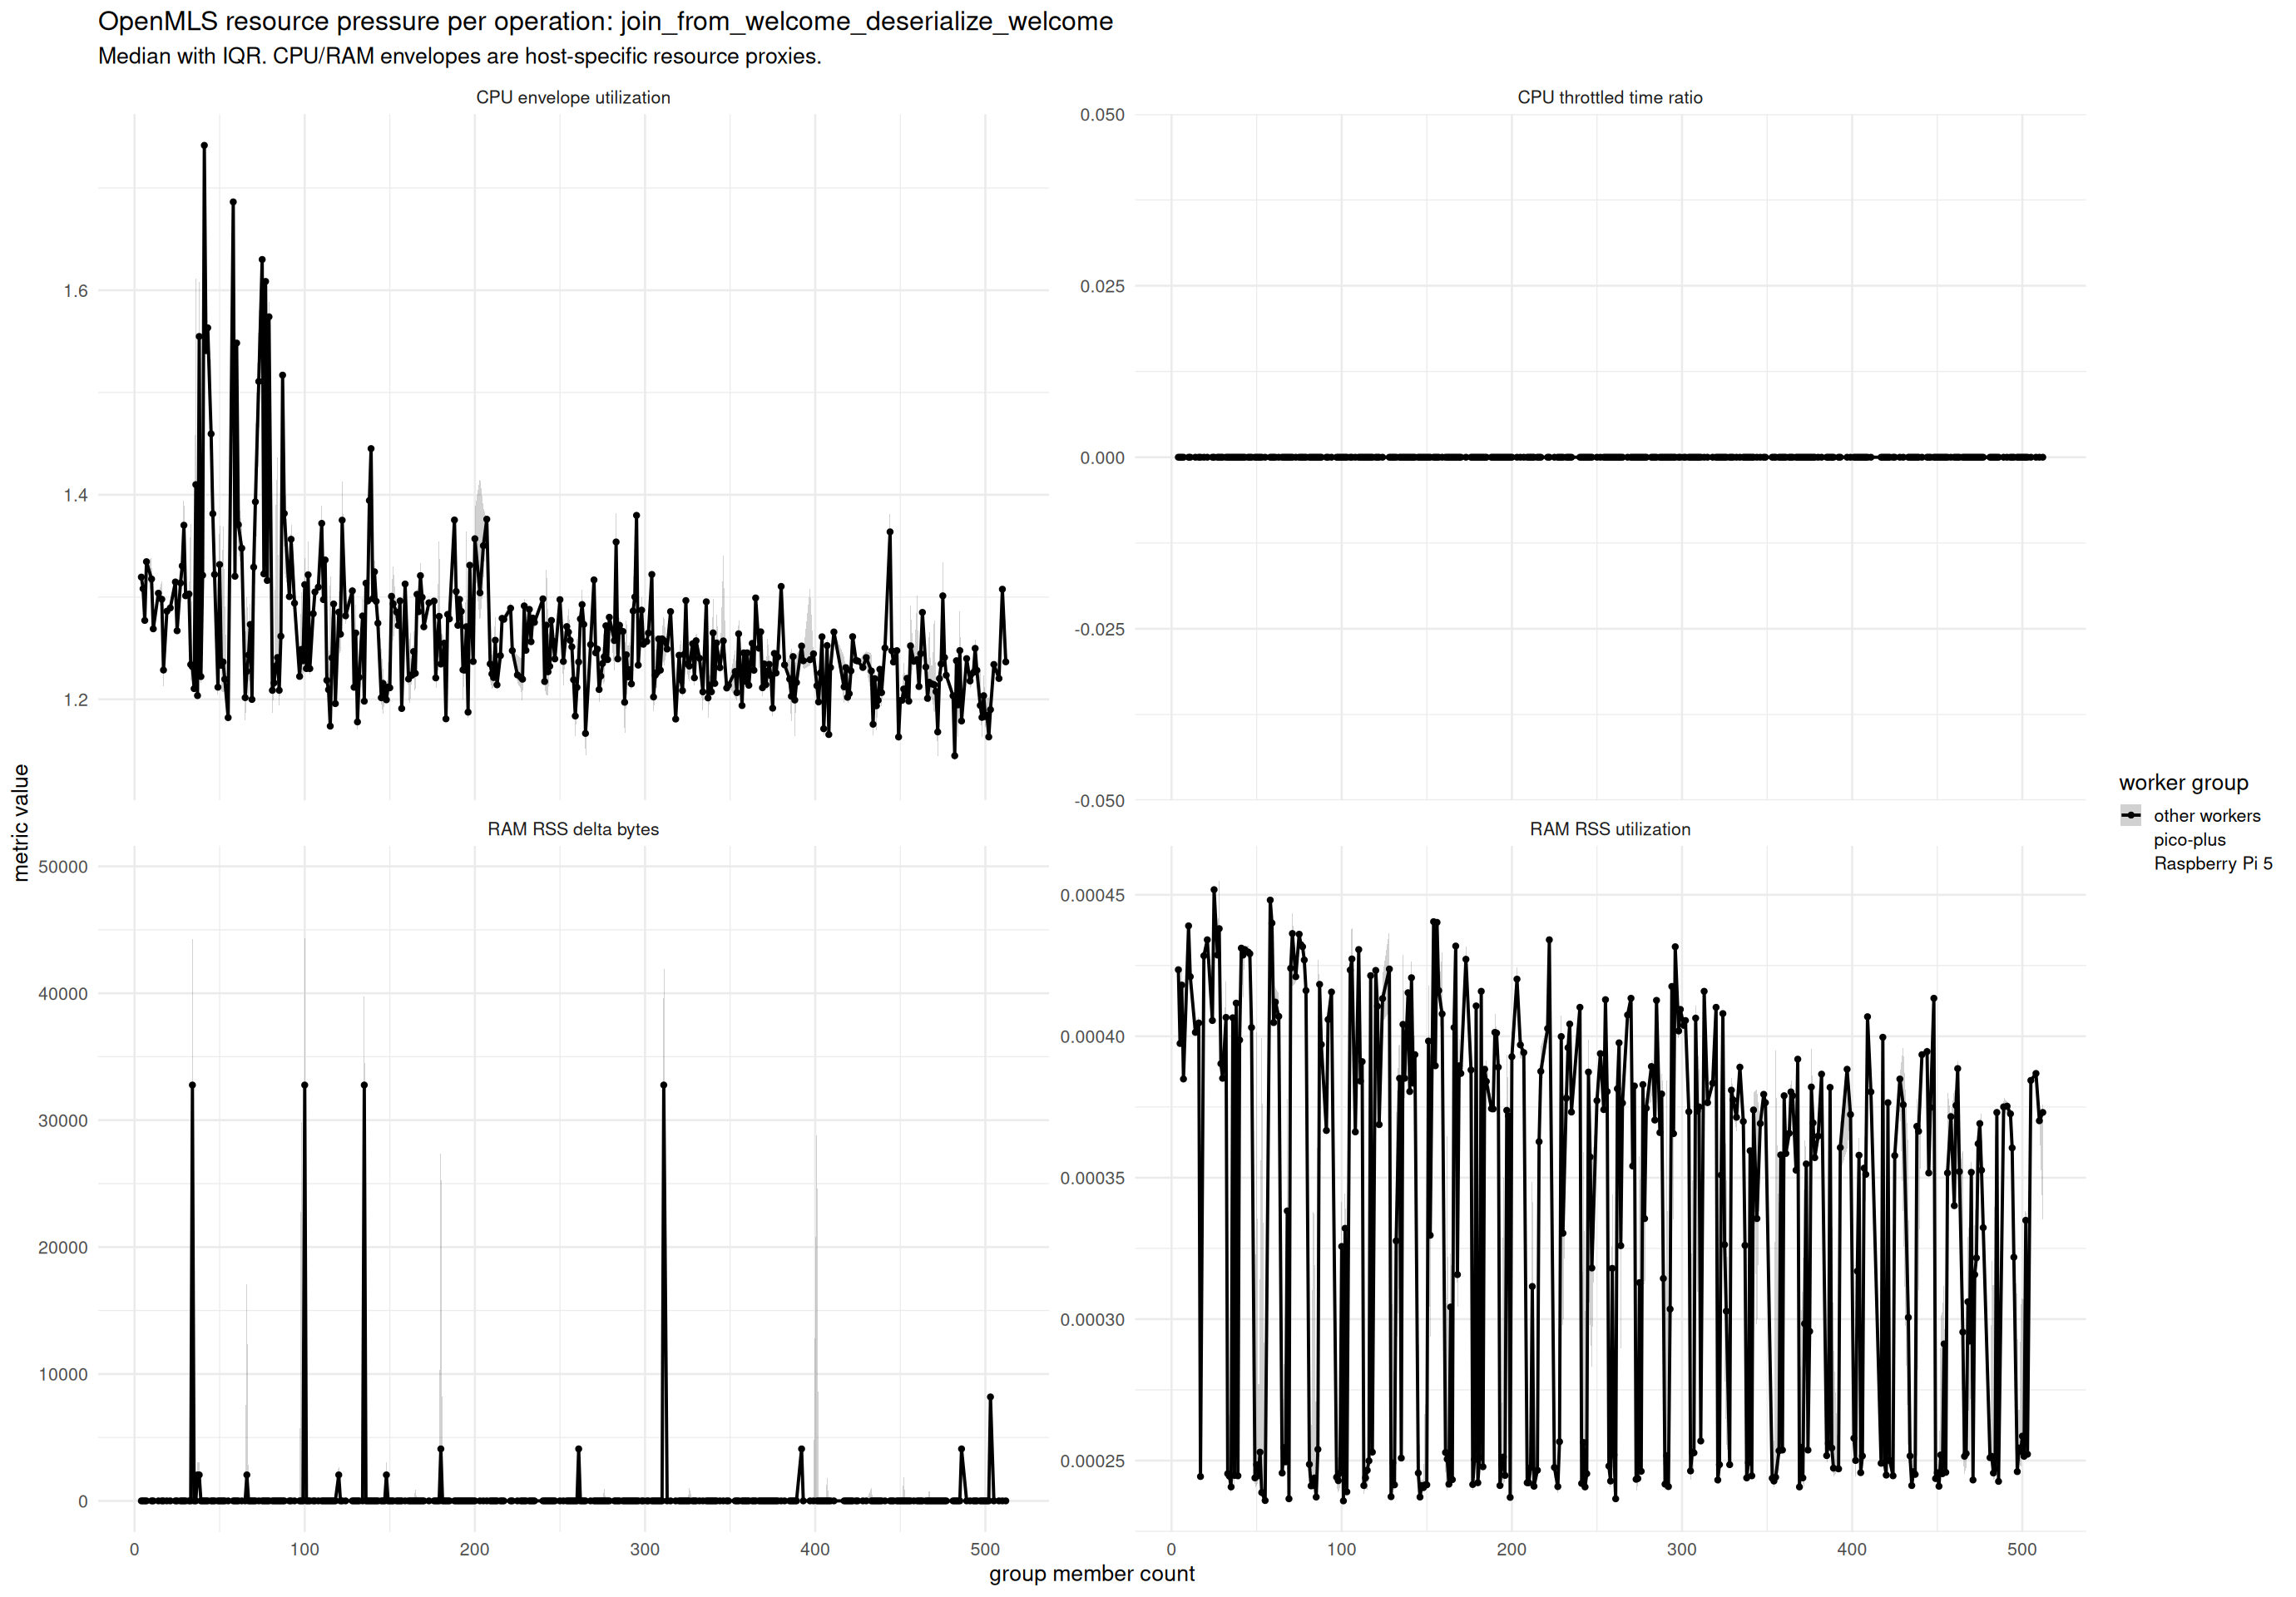

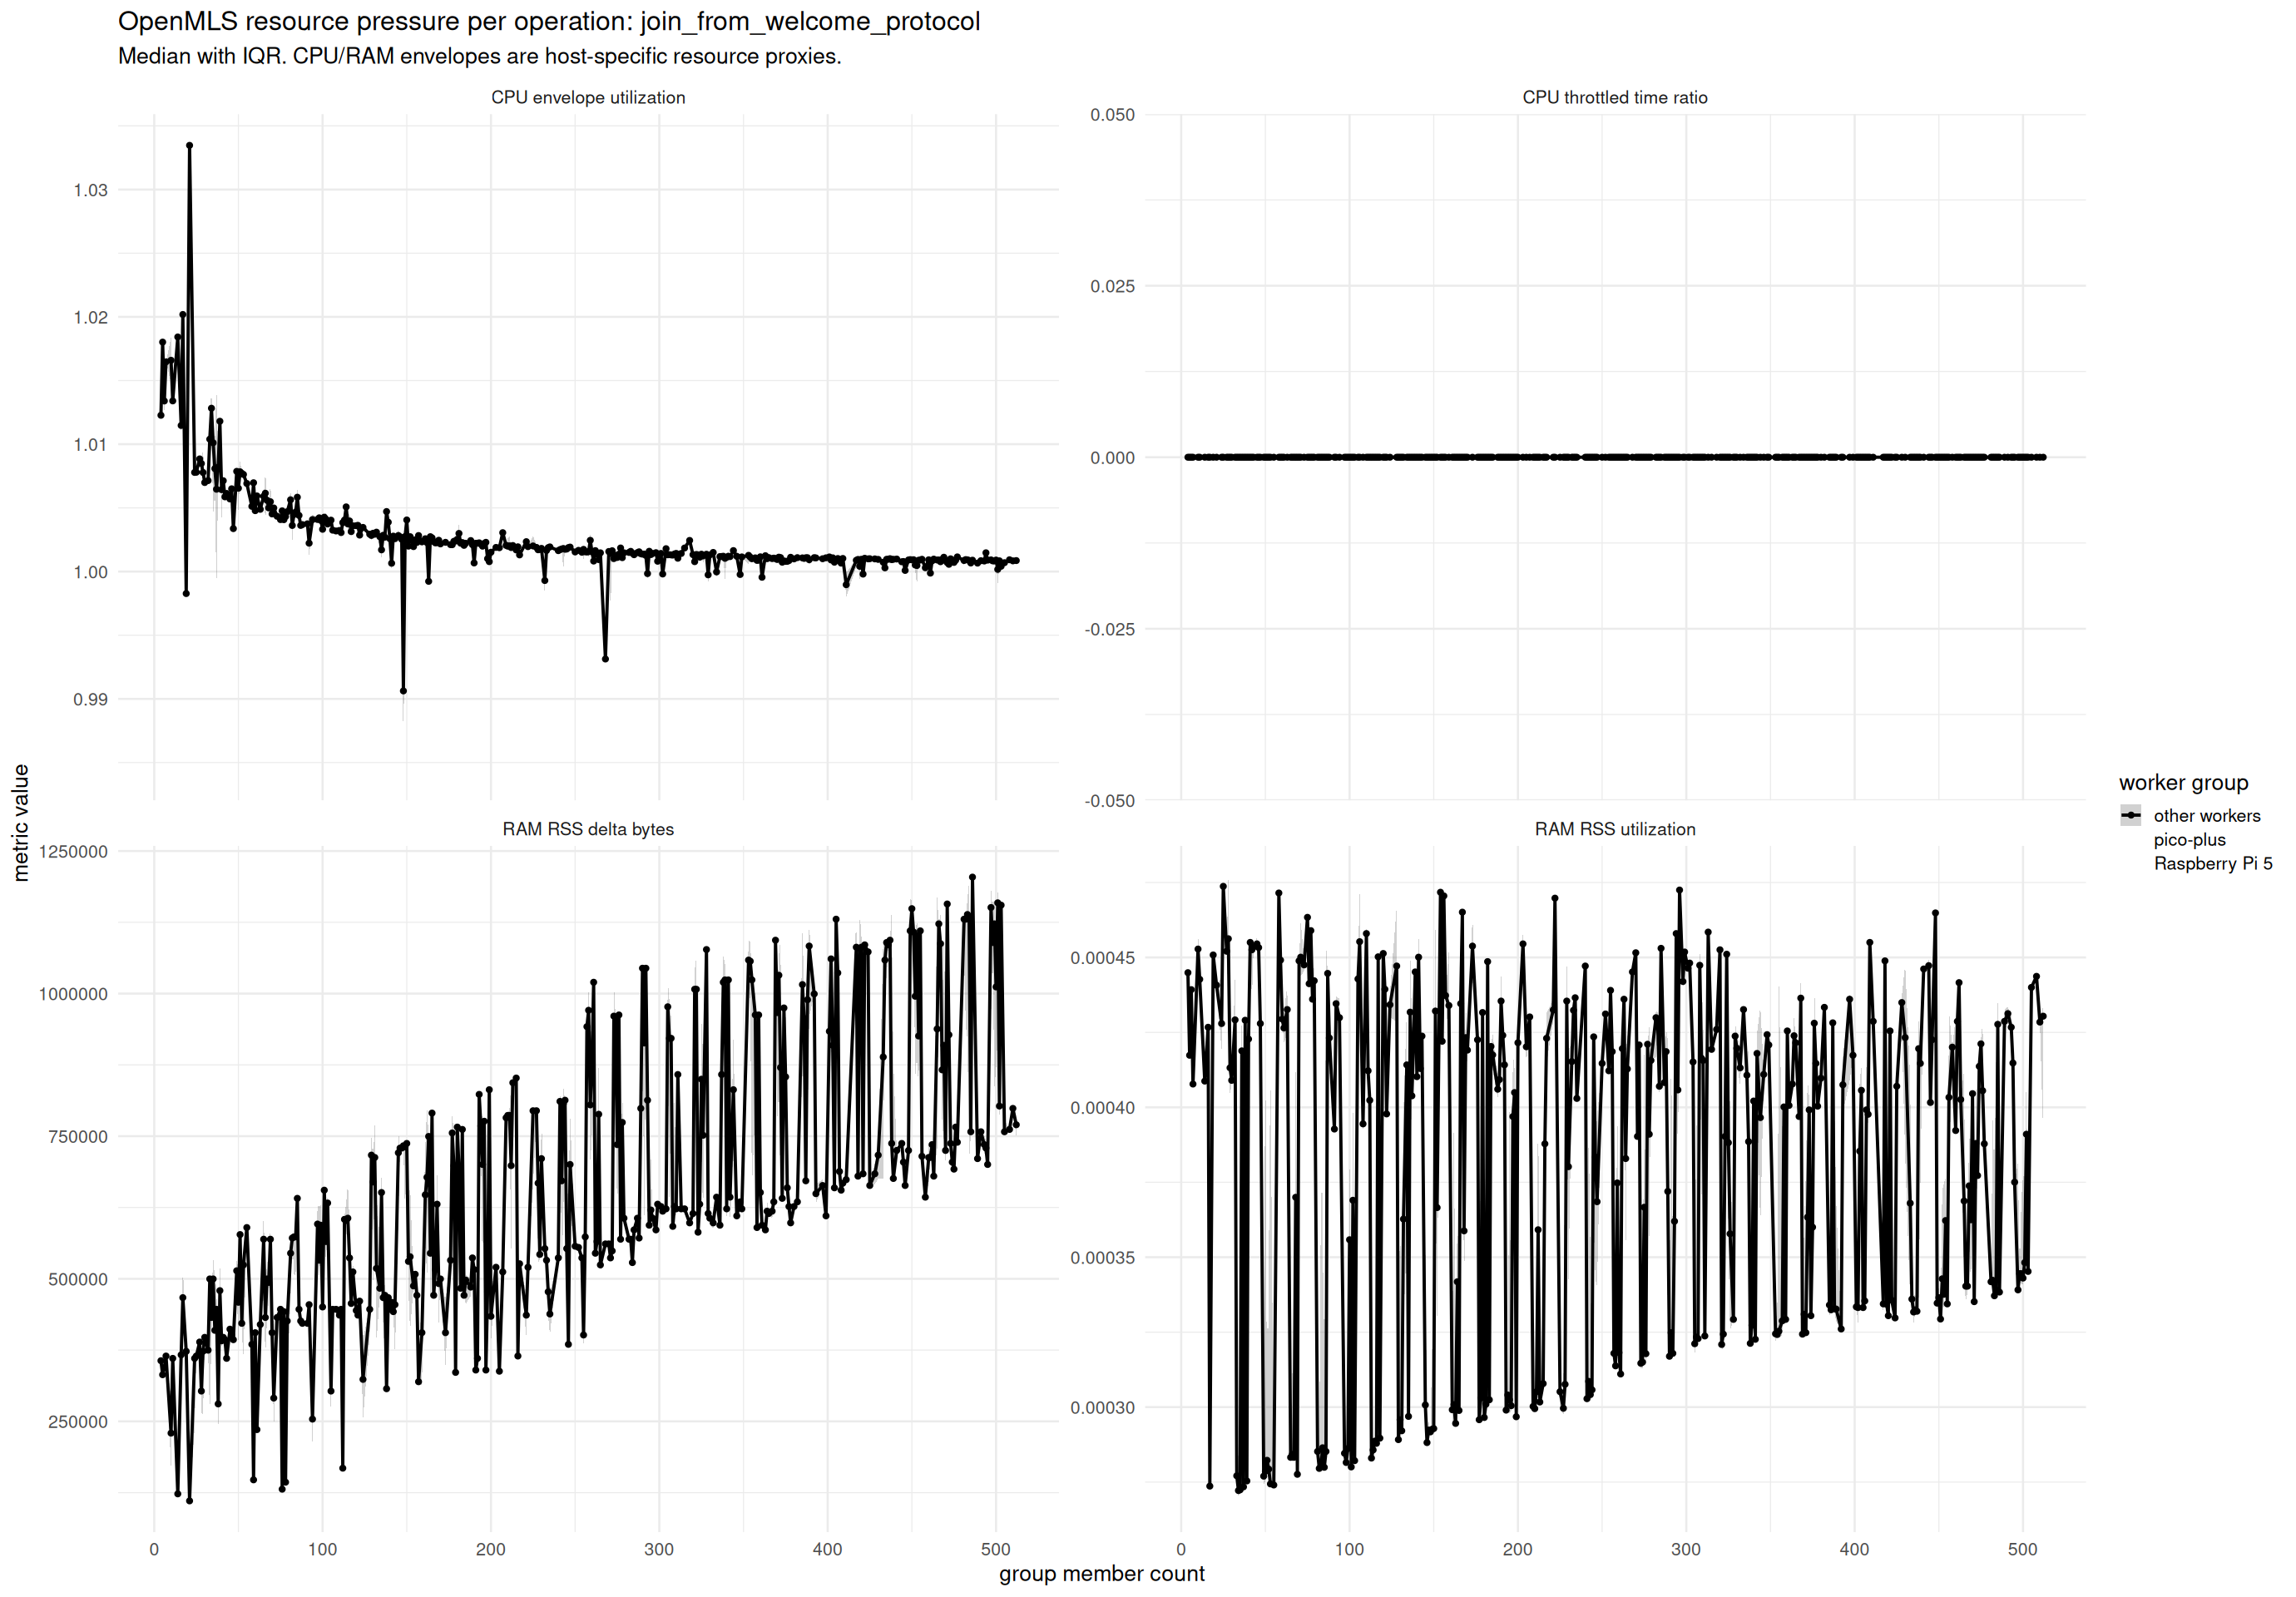

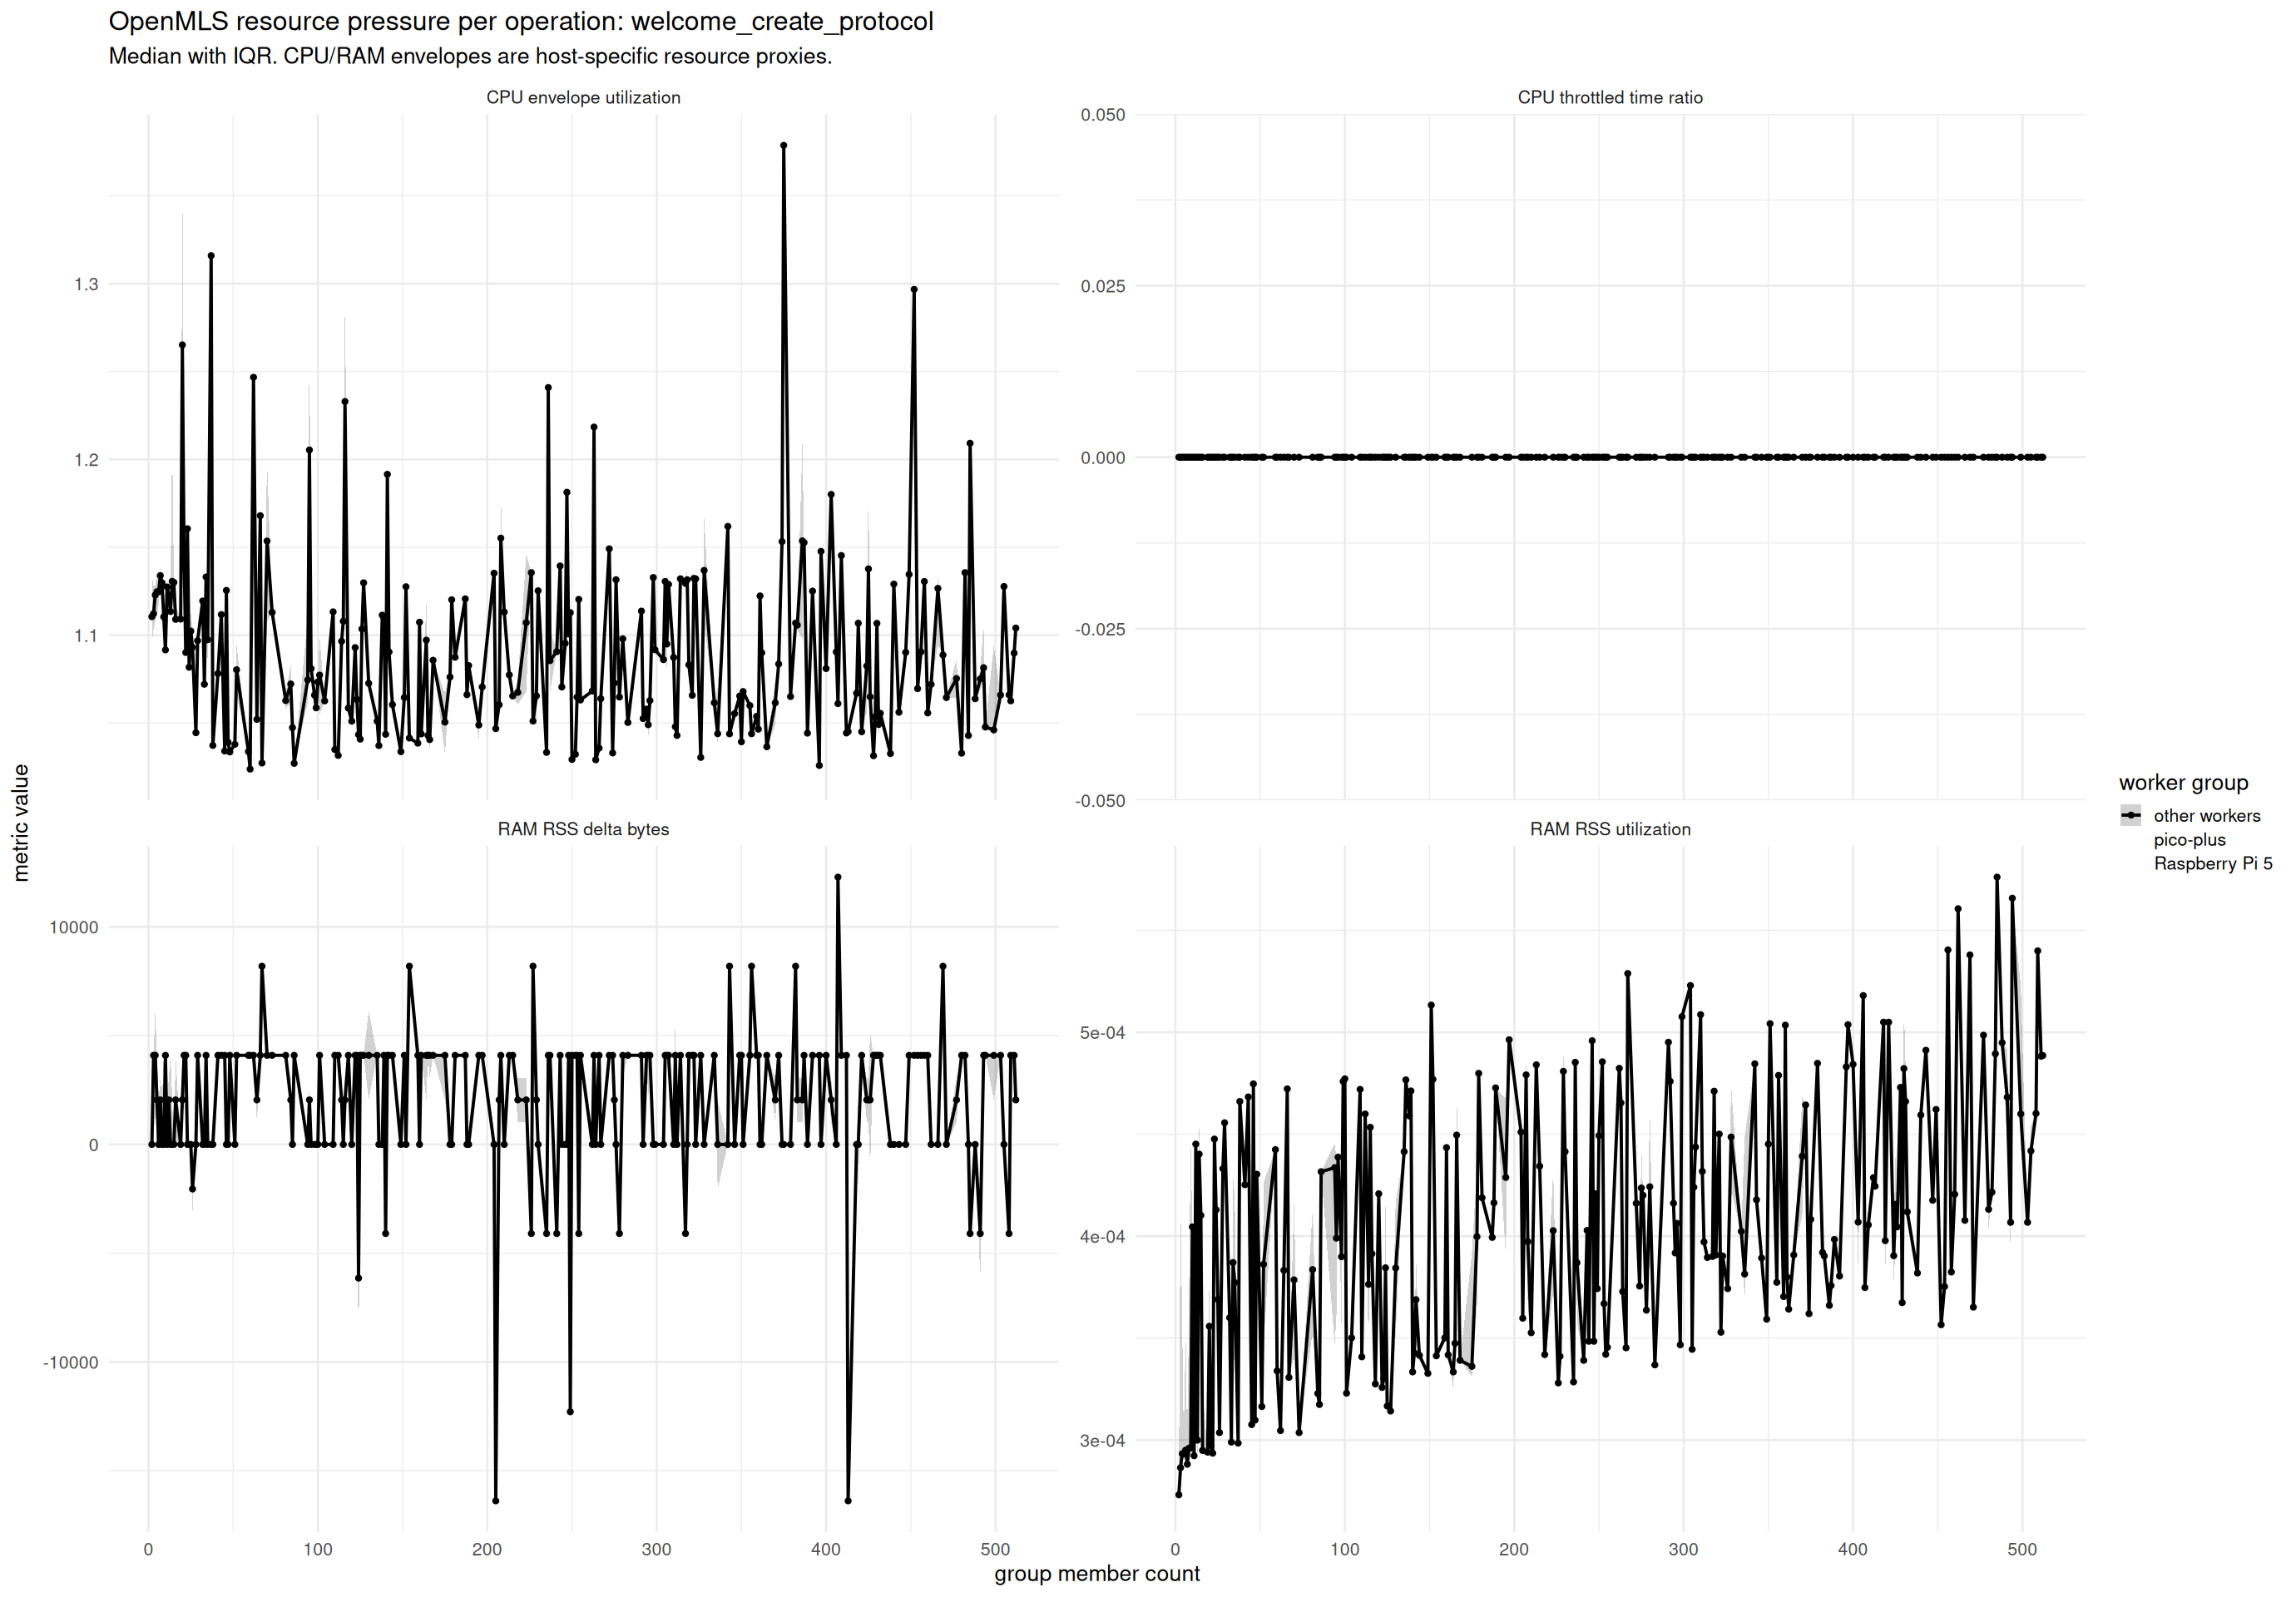

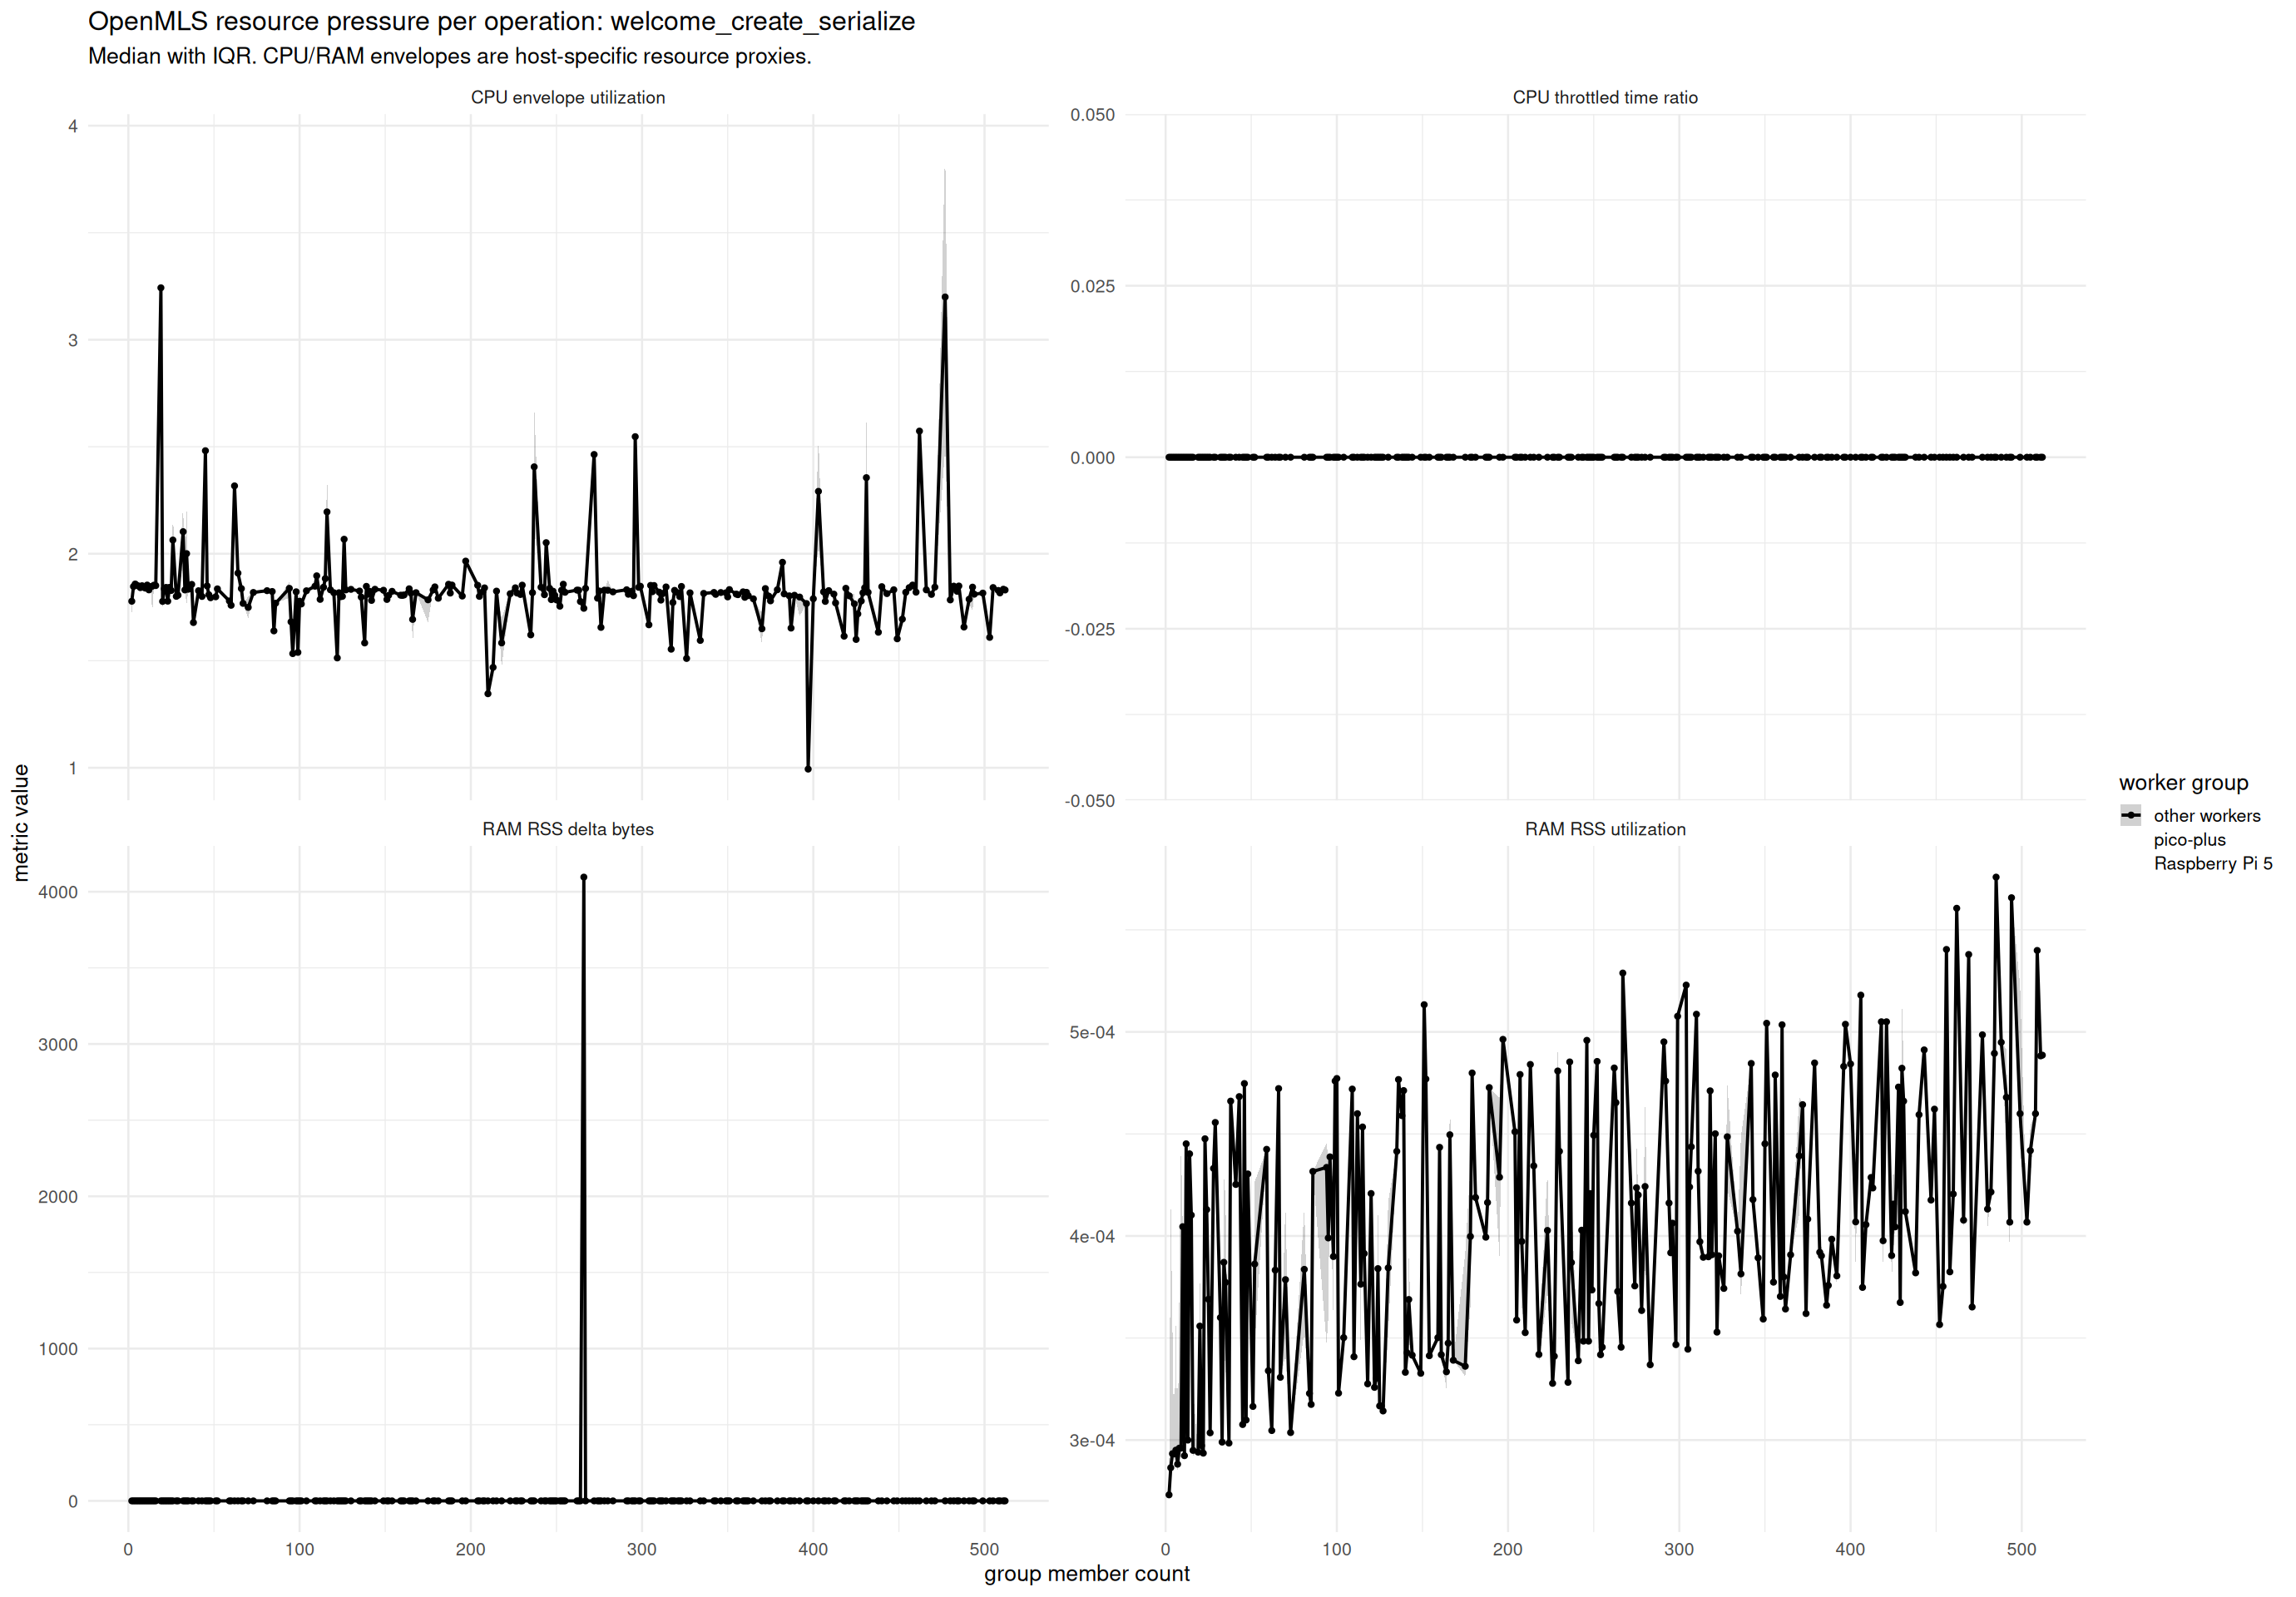

In [5]:
openmls_resource_by_operation <- omls_resource_long |>
  filter(!is.na(value), !is.na(n_members)) |>
  group_by(worker_group, op, metric_label, n_members) |>
  summarise(
    n = n(),
    median = median(value, na.rm = TRUE),
    q25 = quantile(value, 0.25, na.rm = TRUE),
    q75 = quantile(value, 0.75, na.rm = TRUE),
    .groups = "drop"
  ) |>
  filter(n > 0)

for (operation in sort(unique(openmls_resource_by_operation$op))) {
  plot_data <- openmls_resource_by_operation |>
    filter(op == operation)

  p <- ggplot(
    plot_data,
    aes(
      x = n_members,
      color = worker_group,
      fill = worker_group,
      group = worker_group
    )
  ) +
    geom_ribbon(aes(ymin = q25, ymax = q75), alpha = 0.18, color = NA) +
    geom_line(aes(y = median), linewidth = 1.1) +
    geom_point(aes(y = median), size = 1.4) +
    facet_wrap(~metric_label, scales = "free_y", labeller = label_wrap_gen(width = 32)) +
    scale_color_manual(values = openmls_worker_palette, drop = FALSE) +
    scale_fill_manual(values = openmls_worker_palette, drop = FALSE) +
    labs(
      title = glue("OpenMLS resource pressure per operation: {operation}"),
      subtitle = "Median with IQR. CPU/RAM envelopes are host-specific resource proxies.",
      x = "group member count",
      y = "metric value",
      color = "worker group",
      fill = "worker group"
    ) +
    theme_minimal(base_size = 16)

  print(p)
}


## Metric Overview Across Operations

These plots invert the view: one plot per metric, with OpenMLS operations faceted. This is useful for quickly finding which operation dominates a given resource-pressure signal.

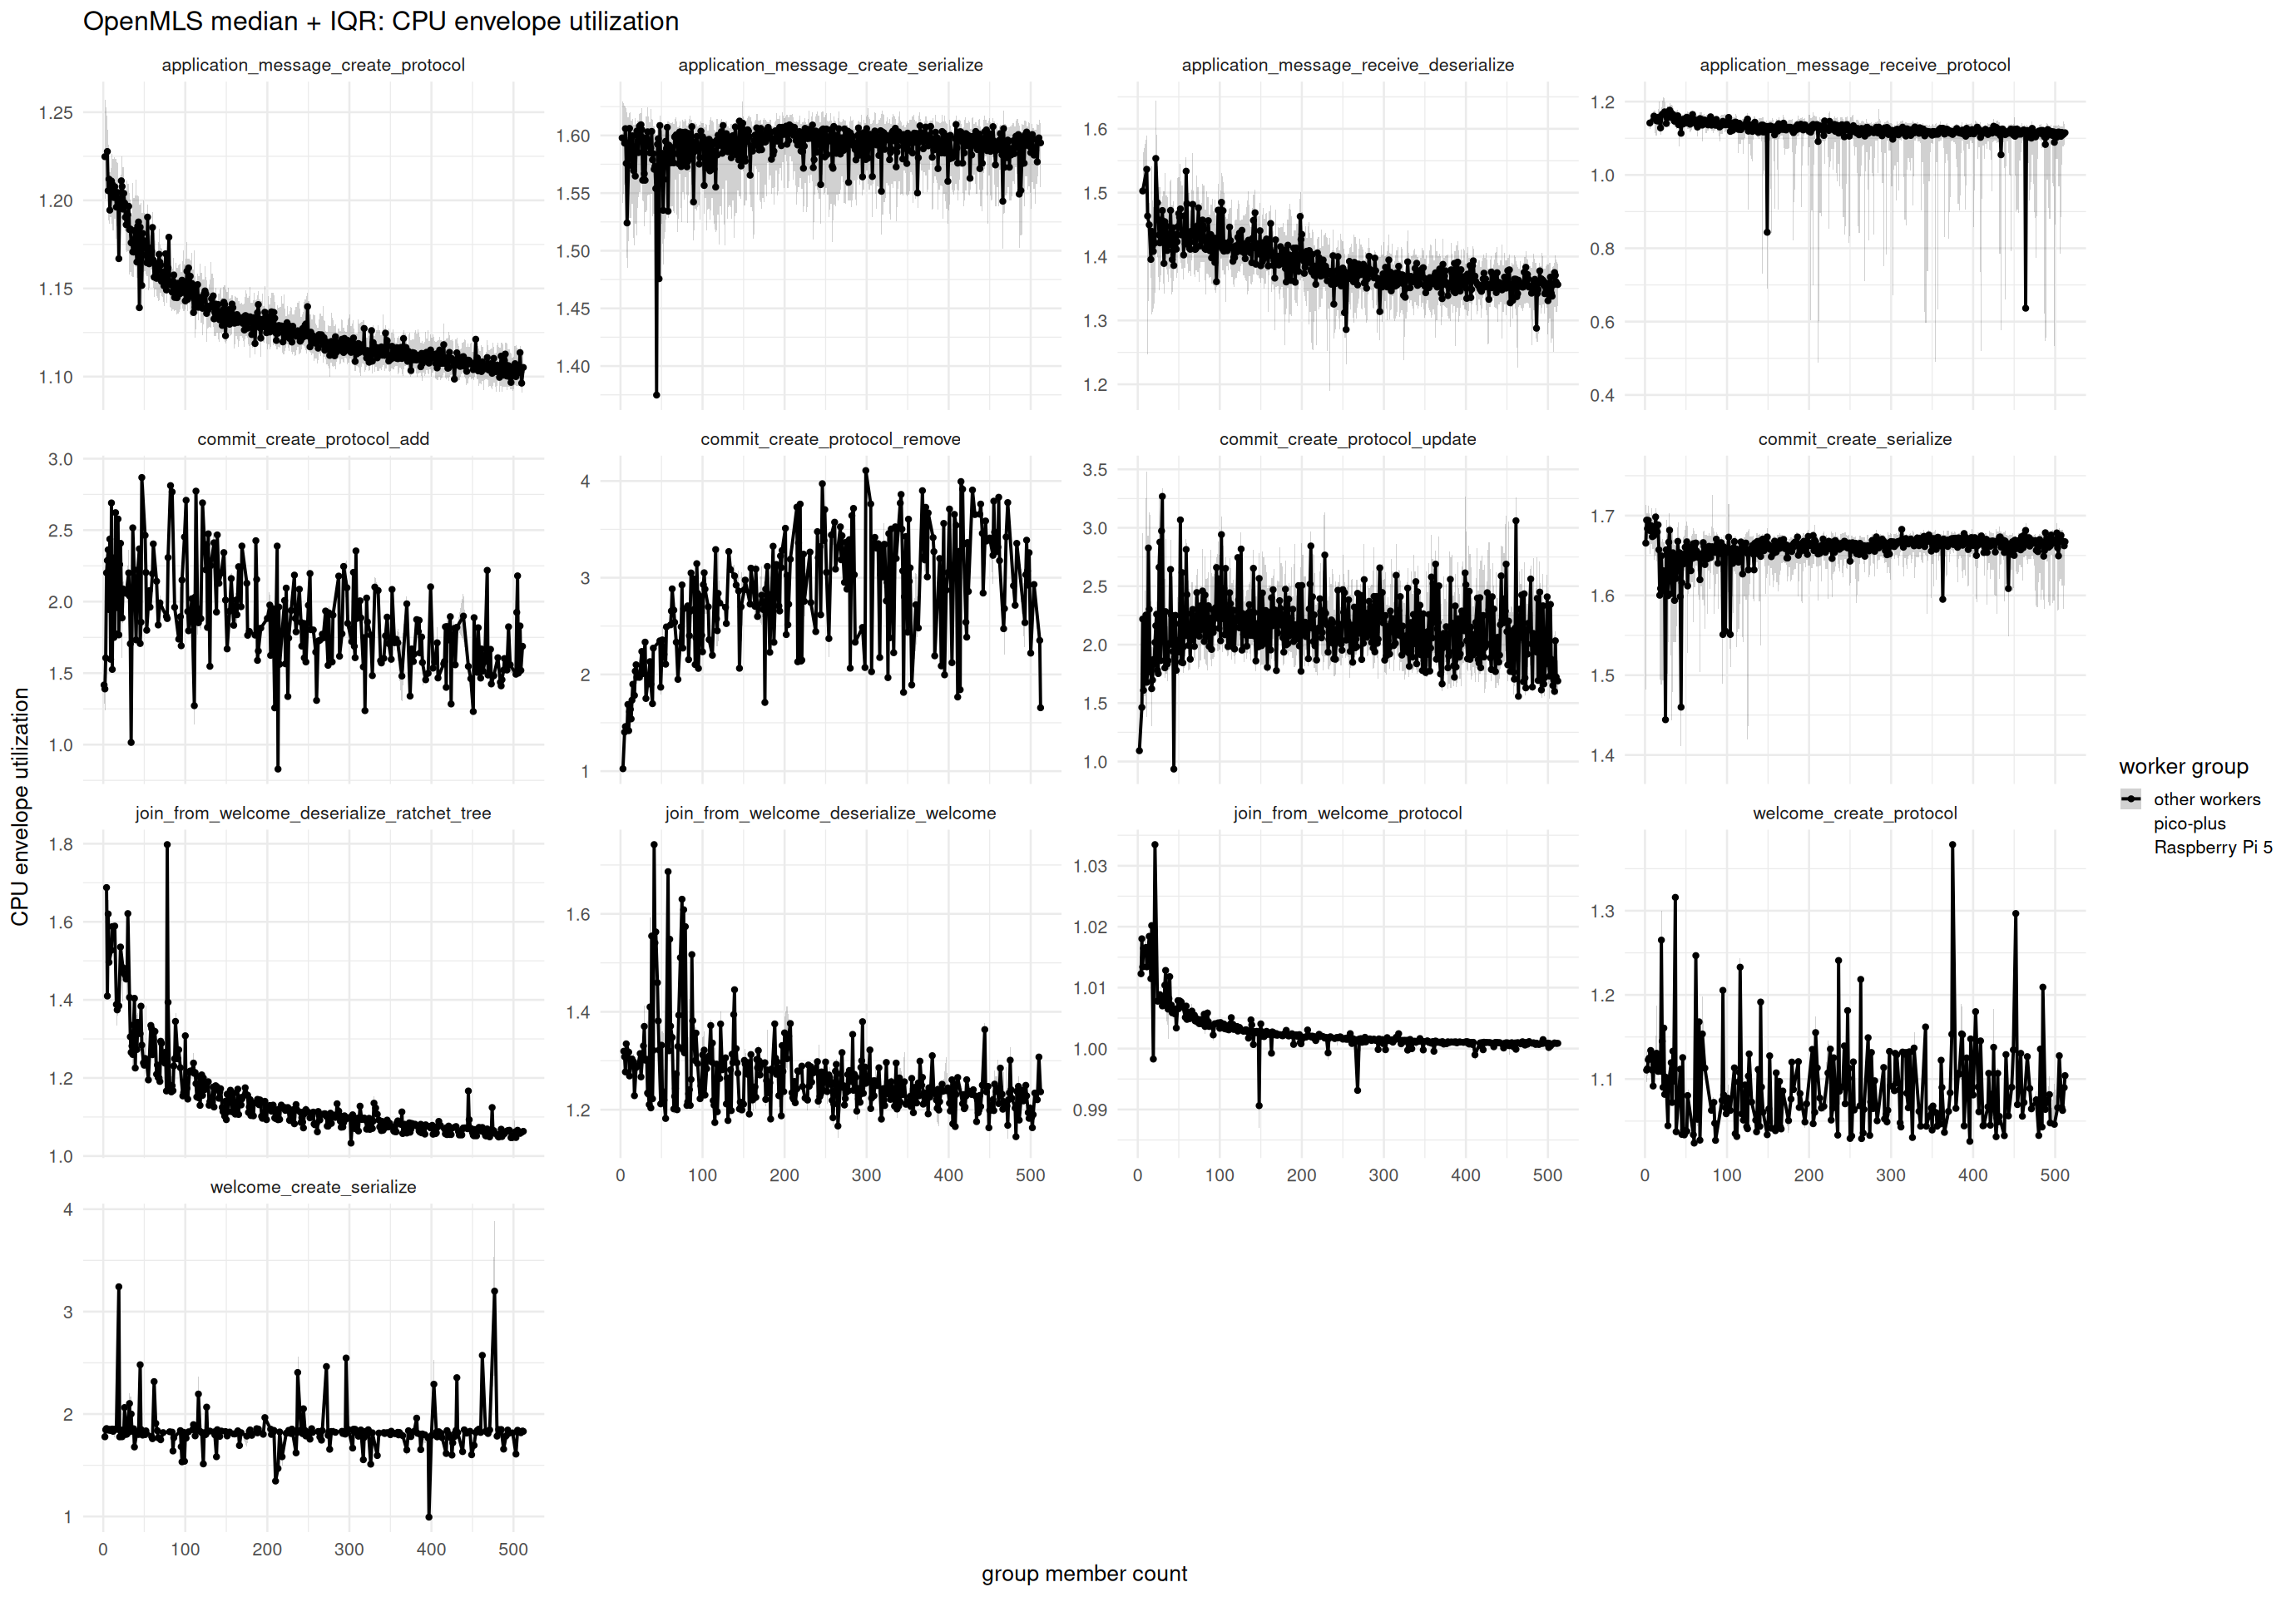

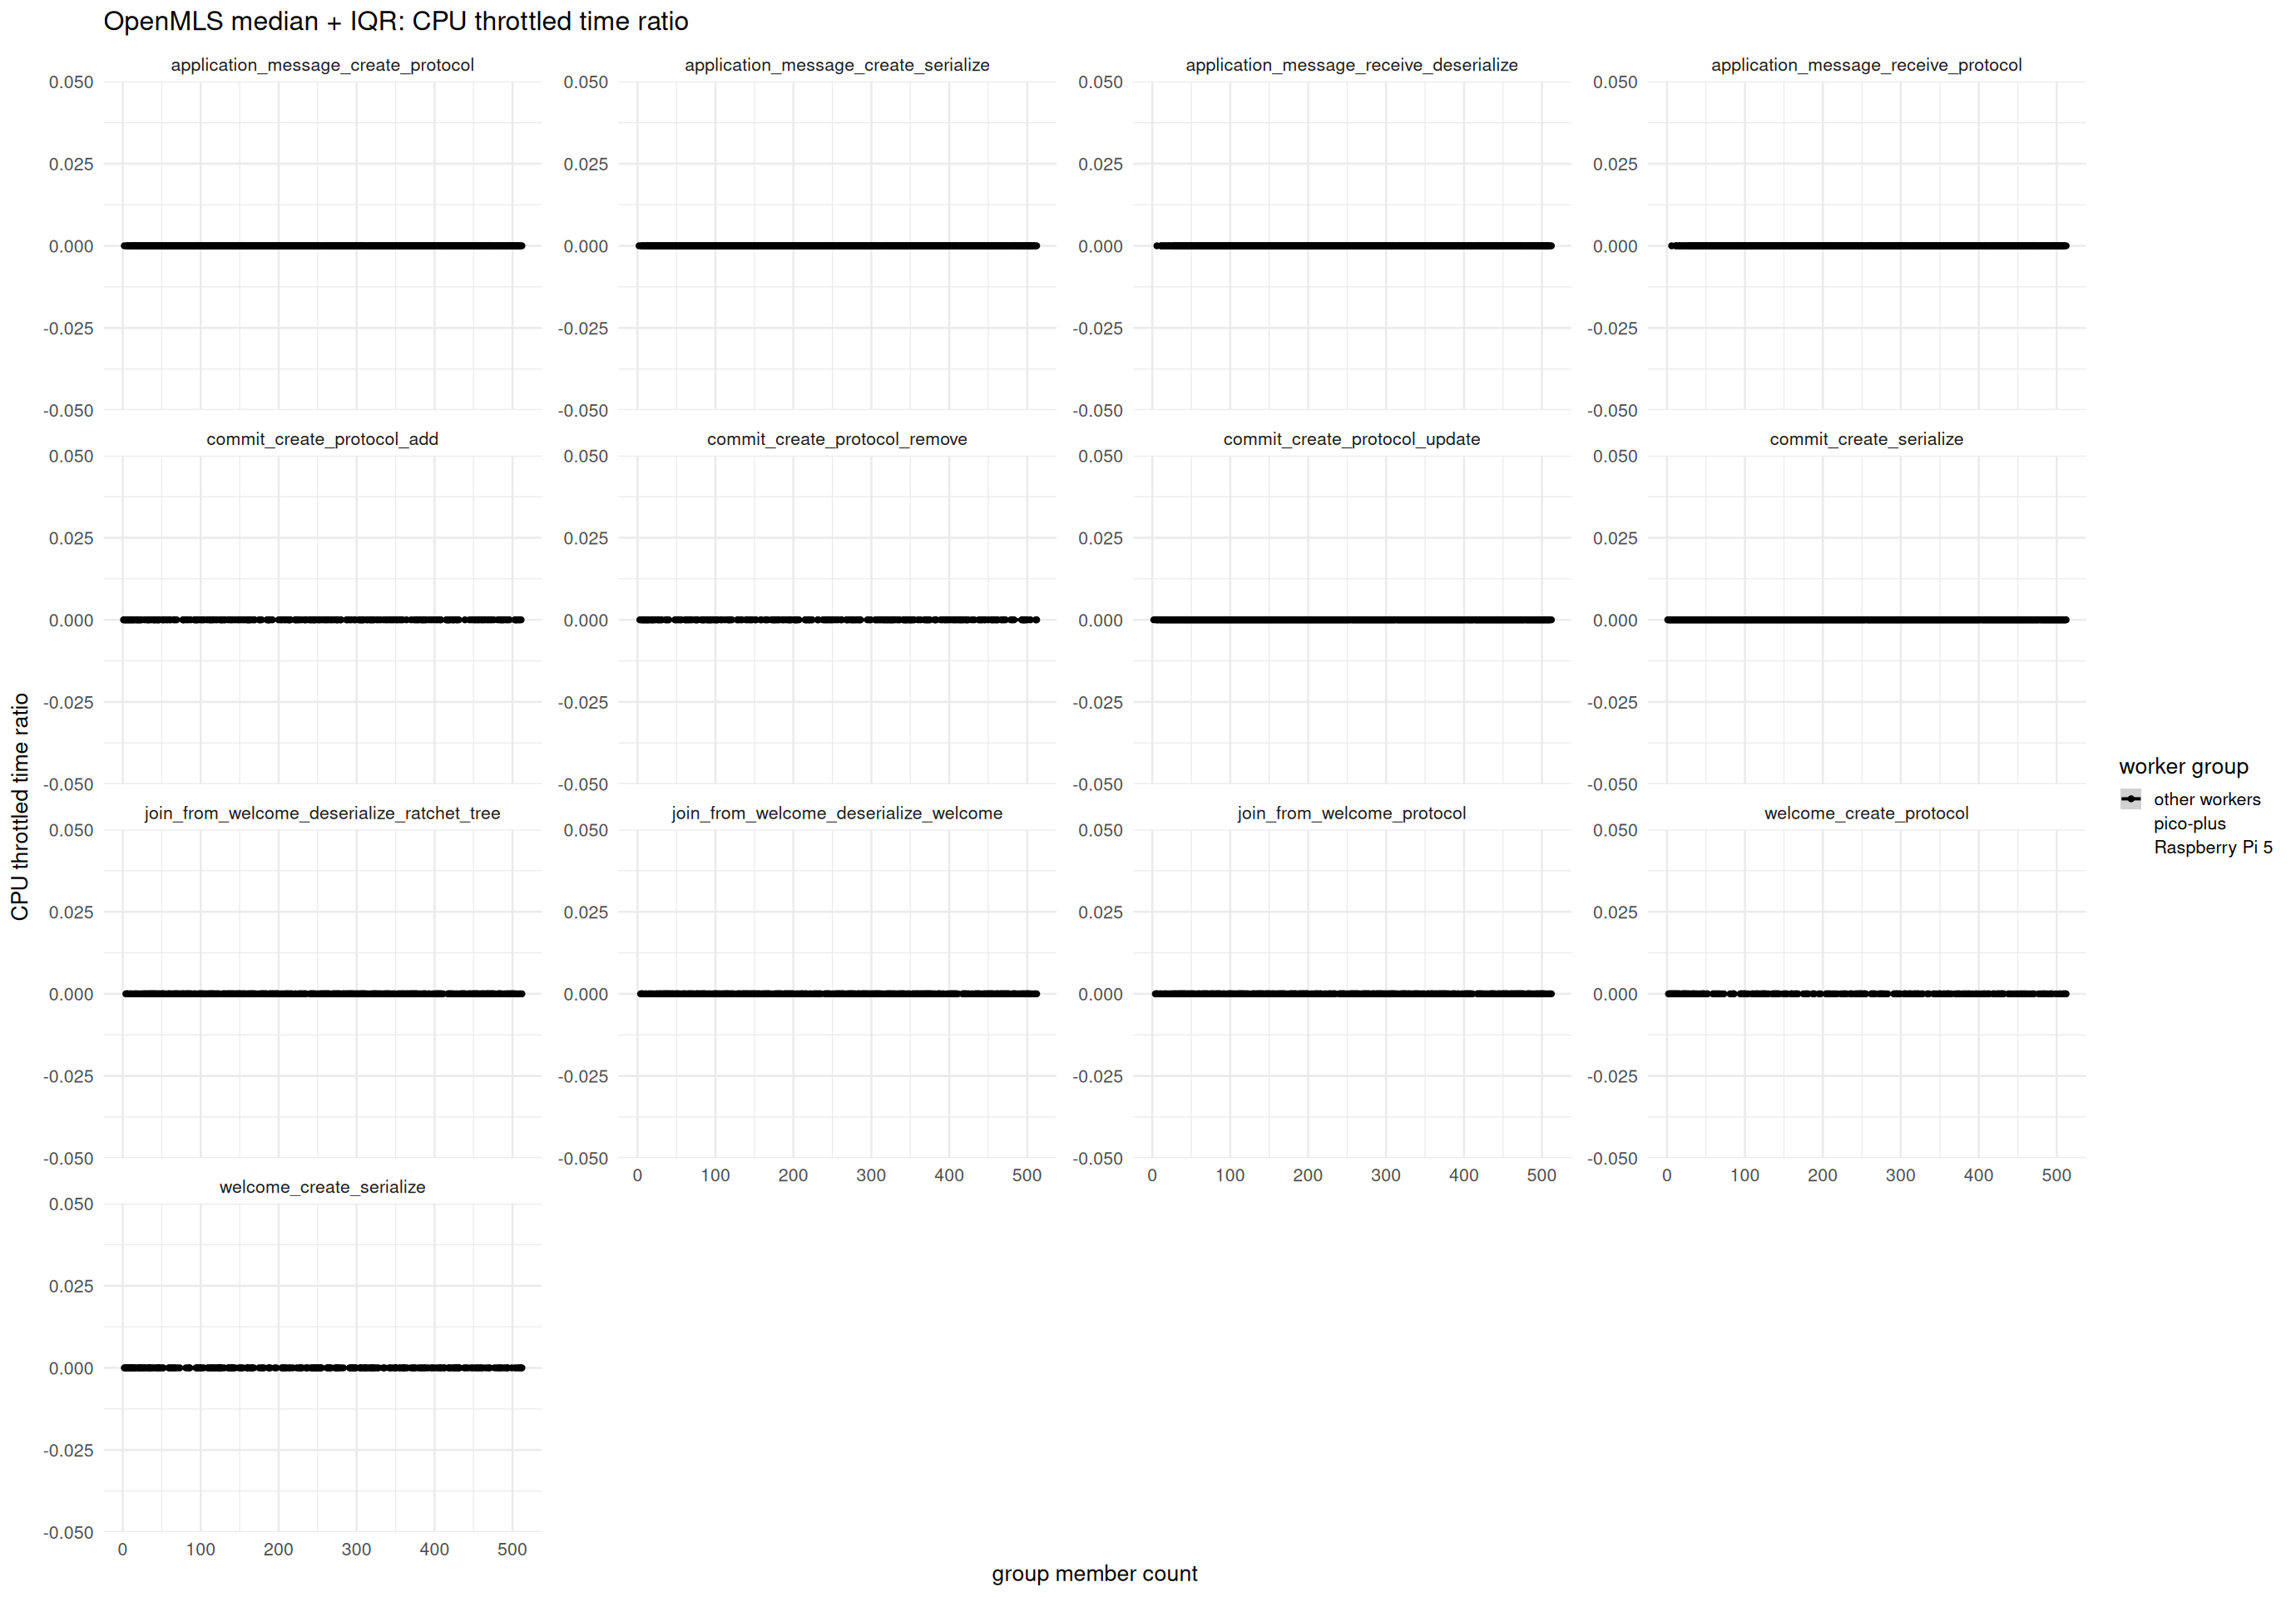

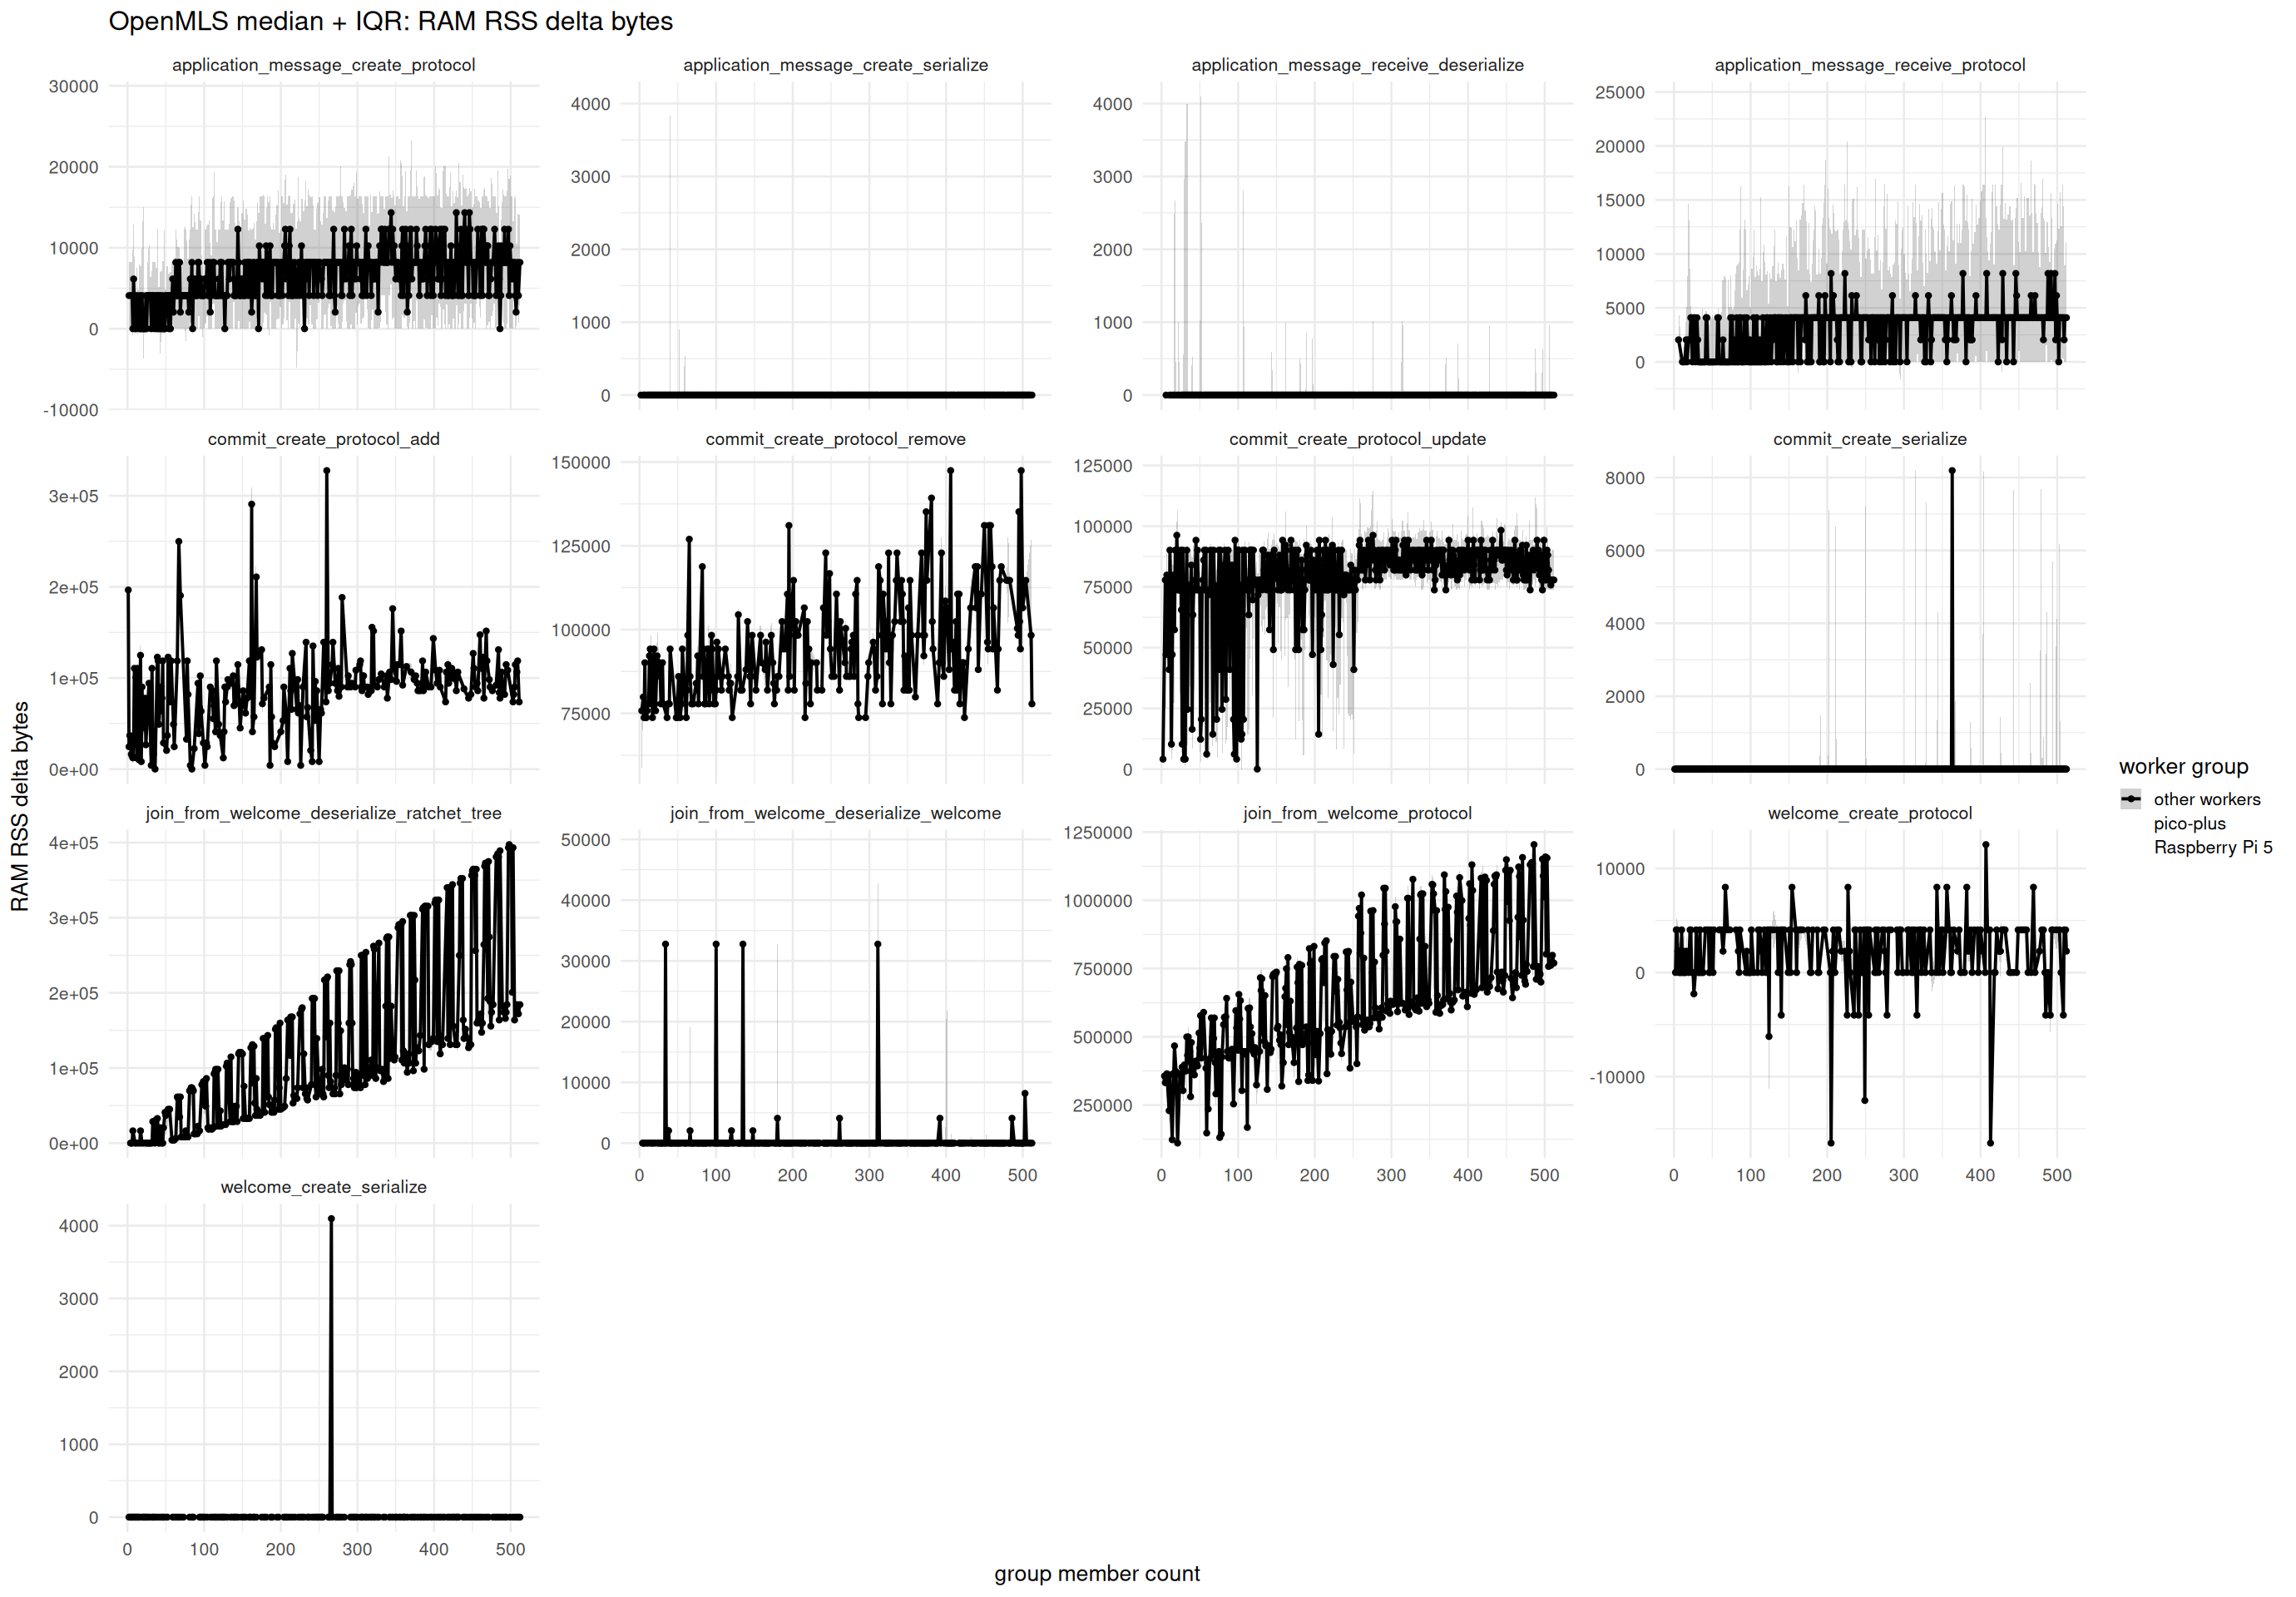

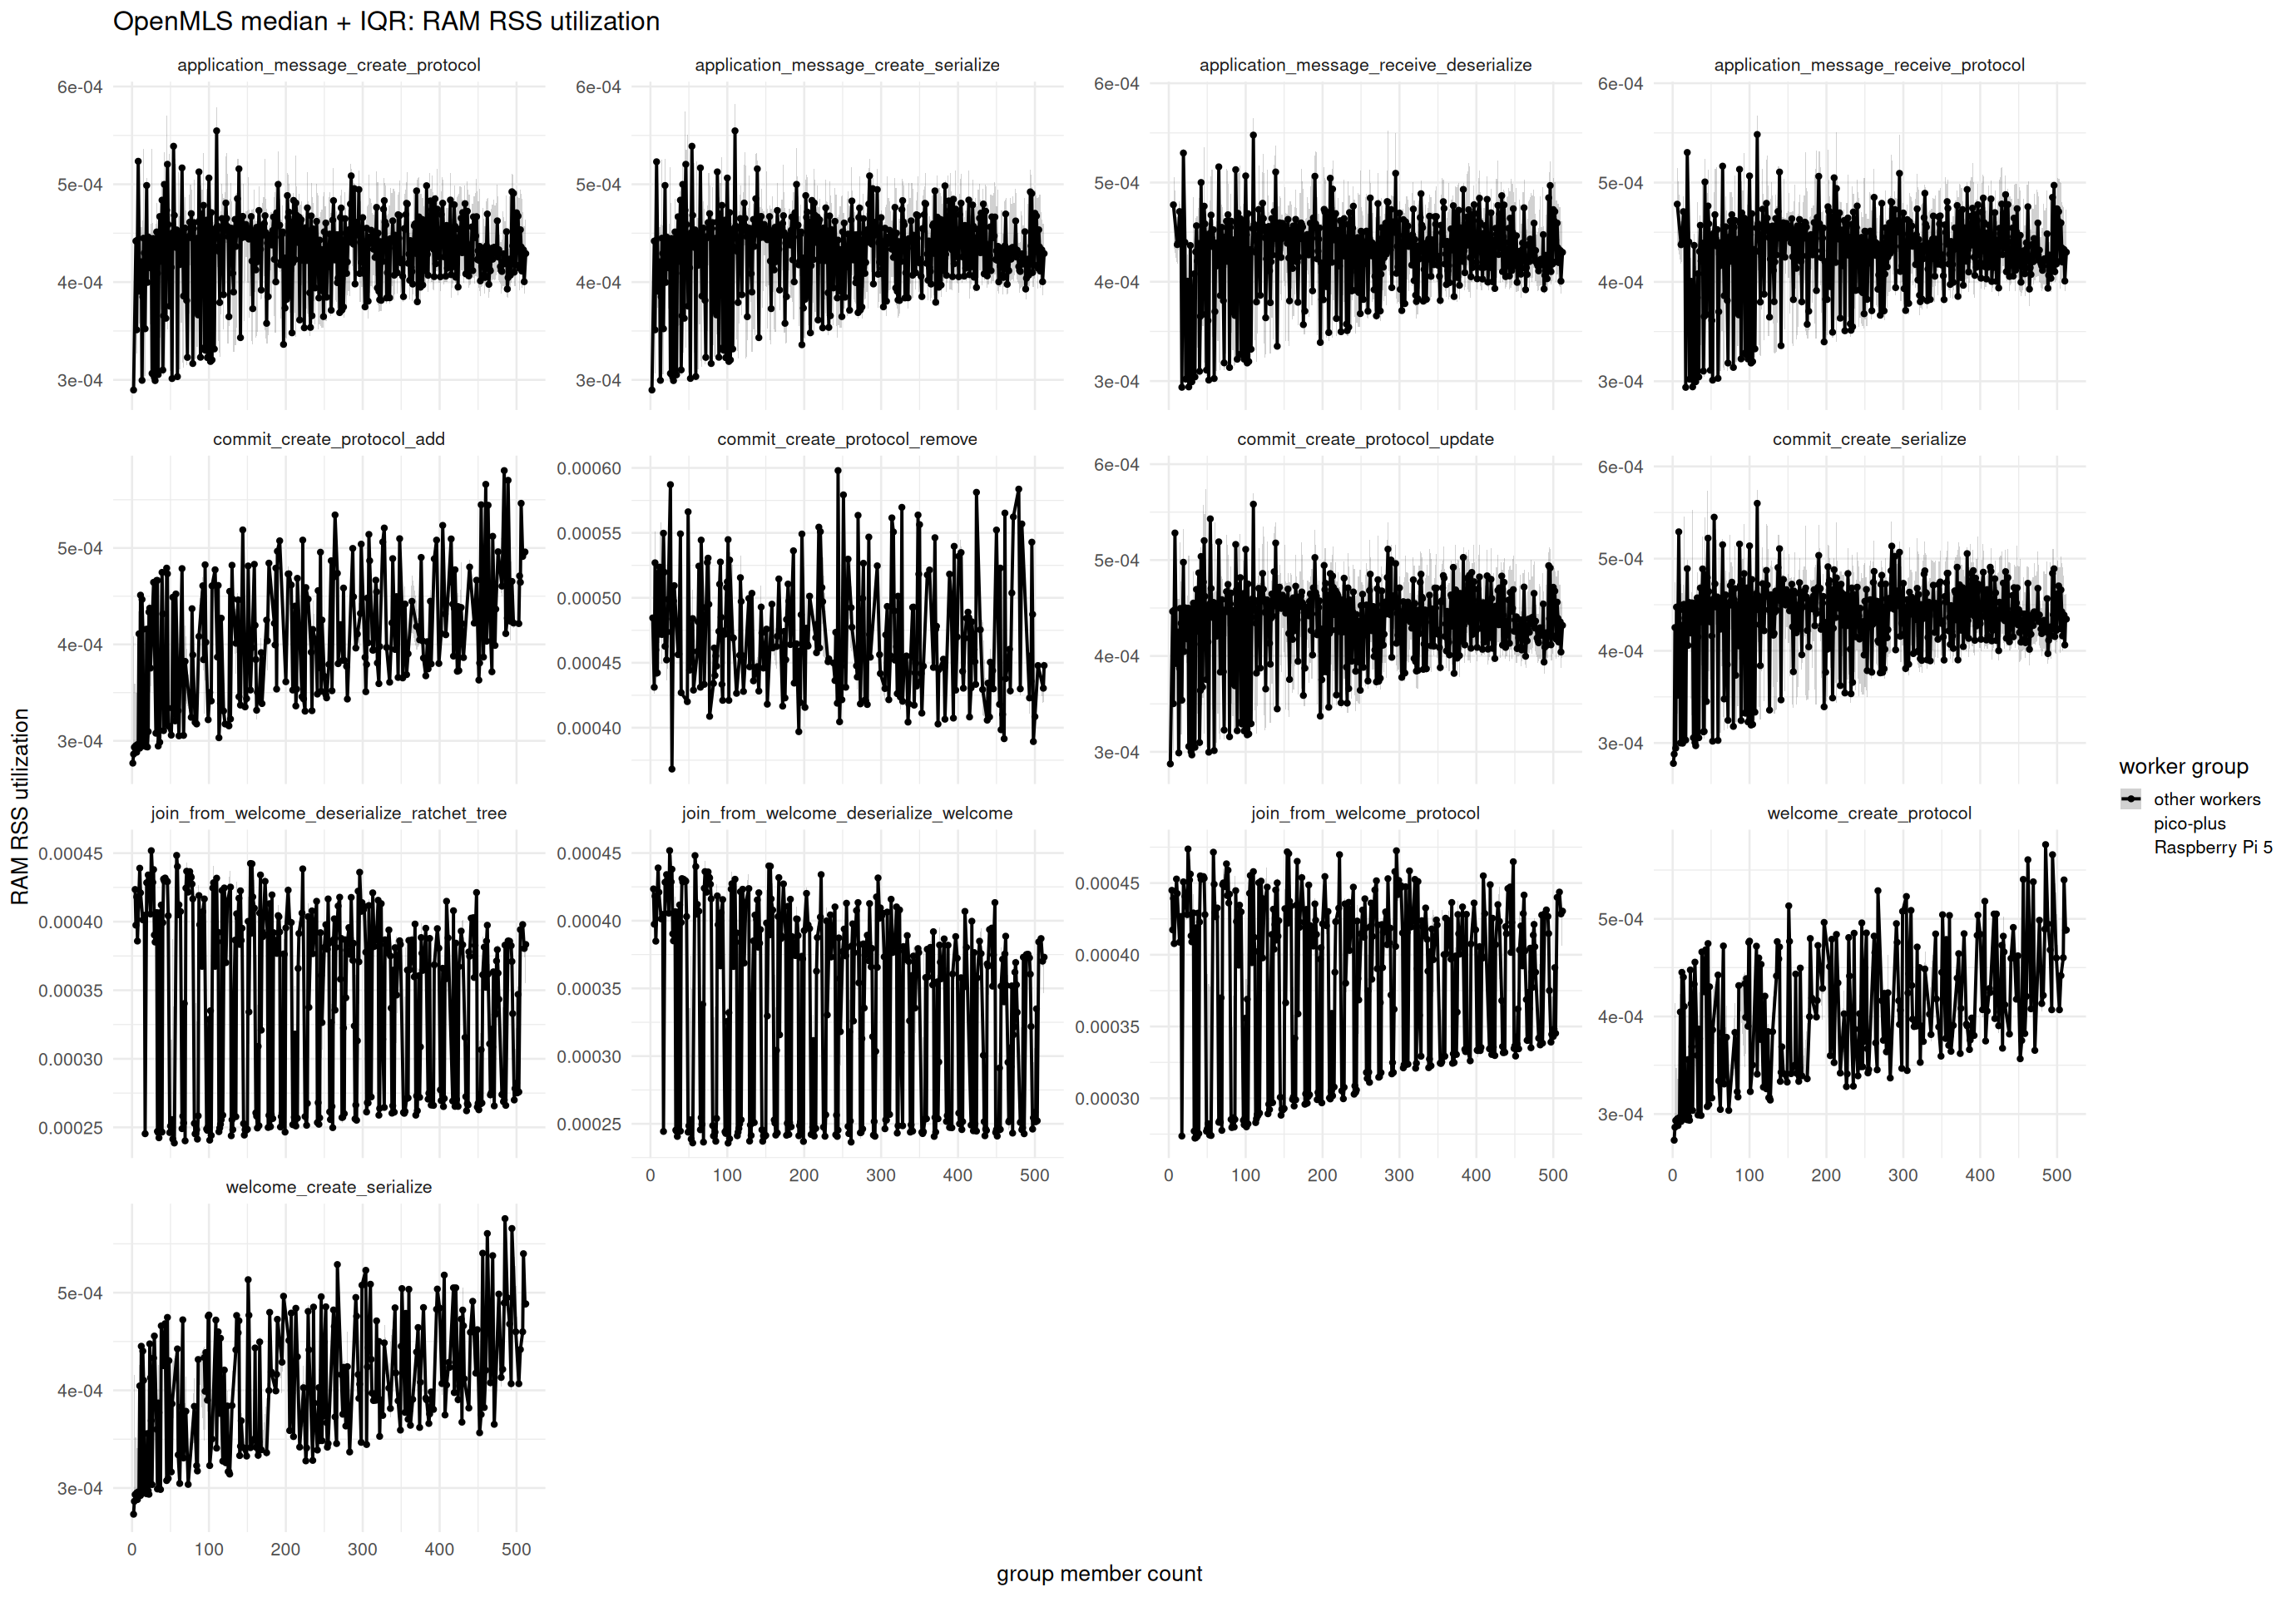

In [6]:
for (metric_name in levels(omls_resource_long$metric_label)) {
  plot_data <- openmls_resource_by_operation |>
    filter(metric_label == metric_name)

  p <- ggplot(
    plot_data,
    aes(
      x = n_members,
      color = worker_group,
      fill = worker_group,
      group = worker_group
    )
  ) +
    geom_ribbon(aes(ymin = q25, ymax = q75), alpha = 0.18, color = NA) +
    geom_line(aes(y = median), linewidth = 1.1) +
    geom_point(aes(y = median), size = 1.4) +
    facet_wrap(~op, scales = "free_y", labeller = label_wrap_gen(width = 28)) +
    scale_color_manual(values = openmls_worker_palette, drop = FALSE) +
    scale_fill_manual(values = openmls_worker_palette, drop = FALSE) +
    labs(
      title = glue("OpenMLS median + IQR: {metric_name}"),
      x = "group member count",
      y = metric_name,
      color = "worker group",
      fill = "worker group"
    ) +
    theme_minimal(base_size = 16)

  print(p)
}
